## Imports

In [56]:
import warnings

import datetime as dt

import numpy as np 
import pandas as pd 

import os

import json

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency

from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import svm

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support, accuracy_score

## Config

In [57]:
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

## Global variables

In [58]:
LABELED_DATA_PATH = "/kaggle/input/184-702-tu-ml-2025w-breast-cancer/breast-cancer-diagnostic.shuf.lrn.csv"
UNLABELED_DATA_PATH = "/kaggle/input/184-702-tu-ml-2025w-breast-cancer/breast-cancer-diagnostic.shuf.tes.csv"

In [59]:
METRICS = {}

## Data Ingestion

In [60]:
df_raw_labeled = pd.read_csv(LABELED_DATA_PATH)
df_raw_test = pd.read_csv(UNLABELED_DATA_PATH)

In [61]:
df_raw_labeled.columns = [c.strip() for c in df_raw_labeled.columns]
df_raw_test.columns = [c.strip() for c in df_raw_test.columns]

In [62]:
display(df_raw_labeled.head())
display(df_raw_test.head())

,ID,class,radiusMean,textureMean,perimeterMean,areaMean,smoothnessMean,compactnessMean,concavityMean,concavePointsMean,...,radiusWorst,textureWorst,perimeterWorst,areaWorst,smoothnessWorst,compactnessWorst,concavityWorst,concavePointsWorst,symmetryWorst,fractalDimensionWorst
0,8813129,False,13.27,17.02,84.55,546.4,0.08445,0.04994,0.03554,0.024560,...,15.14,23.60,98.84,708.8,0.1276,0.1311,0.17860,0.09678,0.2506,0.07623
1,898678,False,12.06,18.90,76.66,445.3,0.08386,0.05794,0.00751,0.008488,...,13.64,27.06,86.54,562.6,0.1289,0.1352,0.04506,0.05093,0.2880,0.08083
2,917896,False,13.71,18.68,88.73,571.0,0.09916,0.10700,0.05385,0.037830,...,15.11,25.63,99.43,701.9,0.1425,0.2566,0.19350,0.12840,0.2849,0.09031
3,869691,True,11.80,16.58,78.99,432.0,0.10910,0.17000,0.16590,0.074150,...,13.74,26.38,91.93,591.7,0.1385,0.4092,0.45040,0.18650,0.5774,0.10300
4,9110127,True,18.03,16.85,117.50,990.0,0.08947,0.12320,0.10900,0.062540,...,20.38,22.02,133.30,1292.0,0.1263,0.2666,0.42900,0.15350,0.2842,0.08225


,ID,radiusMean,textureMean,perimeterMean,areaMean,smoothnessMean,compactnessMean,concavityMean,concavePointsMean,symmetryMean,...,radiusWorst,textureWorst,perimeterWorst,areaWorst,smoothnessWorst,compactnessWorst,concavityWorst,concavePointsWorst,symmetryWorst,fractalDimensionWorst
0,884437,10.480,19.86,66.72,337.7,0.10700,0.05971,0.04831,0.03070,0.1737,...,11.48,29.46,73.68,402.8,0.15150,0.1026,0.1181,0.06736,0.2883,0.07748
1,901011,11.140,14.07,71.24,384.6,0.07274,0.06064,0.04505,0.01471,0.1690,...,12.12,15.82,79.62,453.5,0.08864,0.1256,0.1201,0.03922,0.2576,0.07018
2,865432,14.500,10.89,94.28,640.7,0.11010,0.10990,0.08842,0.05778,0.1856,...,15.70,15.98,102.80,745.5,0.13130,0.1788,0.2560,0.12210,0.2889,0.08006
3,894329,9.042,18.90,60.07,244.5,0.09968,0.19720,0.19750,0.04908,0.2330,...,10.06,23.40,68.62,297.1,0.12210,0.3748,0.4609,0.11450,0.3135,0.10550
4,84348301,11.420,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.20980,0.8663,0.6869,0.25750,0.6638,0.17300


# First Iteration

## Initial Analysis

### Nulls

There are no nulls in the dataset

In [63]:
null_summary = pd.concat(
    [
        pd.DataFrame(df_raw_labeled.isna().sum(), columns=["Train/Val"]), 
        pd.DataFrame(df_raw_test.isna().sum(), columns=["Test"])
    ], axis=1)
null_summary

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Train/Val,Test
ID,0,0.0
class,0,NaN
radiusMean,0,0.0
textureMean,0,0.0
perimeterMean,0,0.0
areaMean,0,0.0
smoothnessMean,0,0.0
compactnessMean,0,0.0
concavityMean,0,0.0
concavePointsMean,0,0.0


### Outliers

There are some amount of outliers in the data, but it seems that they are very informative as when many of the features has an outlier data, it is highly correlated with the True class, so we might choose not to handle them in any way. This does not mean necesarily that the outliers in the test dataset may also behave similar, but there is a good chance of that behavior also being present there. Another option would be to exclude them the training, and instead pass the outlier rows through a rules sytem and have the trained models focus on the non outlier rows.

In [64]:
def tag_iqr_outliers(df: pd.DataFrame, col: str) -> pd.DataFrame:
    df_outliers = df[["class", col]].copy()
    
    qs = df_outliers[col].quantile([0.25, 0.75])
    
    iqr = qs[0.75] - qs[0.25]
    
    iqr_lower = qs[0.25] - (1.5*iqr)
    iqr_upper = qs[0.75] + (1.5*iqr)
    
    df_outliers["outlier_cat"] = np.where((df_outliers[col] < iqr_lower) | (df_outliers[col] > iqr_upper), "outlier", "inlier")
    df_outliers = df_outliers[df_outliers["outlier_cat"] == "outlier"]
    
    return df_outliers


def get_numeric_feature_columns(df: pd.DataFrame) -> list:
    num_cols = df.drop(["ID", "class"], axis=1, errors="ignore").select_dtypes(include=np.number).columns
    
    return num_cols


def make_plot_grid_ax(num_cols: list, plot_cols: int = 3, subfigsize: tuple = (20, 5)) -> plt.axis:
    plot_cols = plot_cols
    plot_rows = int(np.ceil((len(num_cols)/plot_cols)))
    
    fig, ax = plt.subplots(plot_rows, plot_cols, figsize=(subfigsize[0], subfigsize[1] * plot_rows))
    ax = ax.flatten()
    
    return ax

def plot_box_grid(df: pd.DataFrame, subfigsize: tuple = (20, 5)) -> None:
    num_cols = get_numeric_feature_columns(df=df)

    ax = make_plot_grid_ax(num_cols=num_cols, plot_cols=3, subfigsize=subfigsize)
    
    for i, col in enumerate(num_cols):
        sns.boxplot(data=df, y=col, ax=ax[i])

    plt.tight_layout()

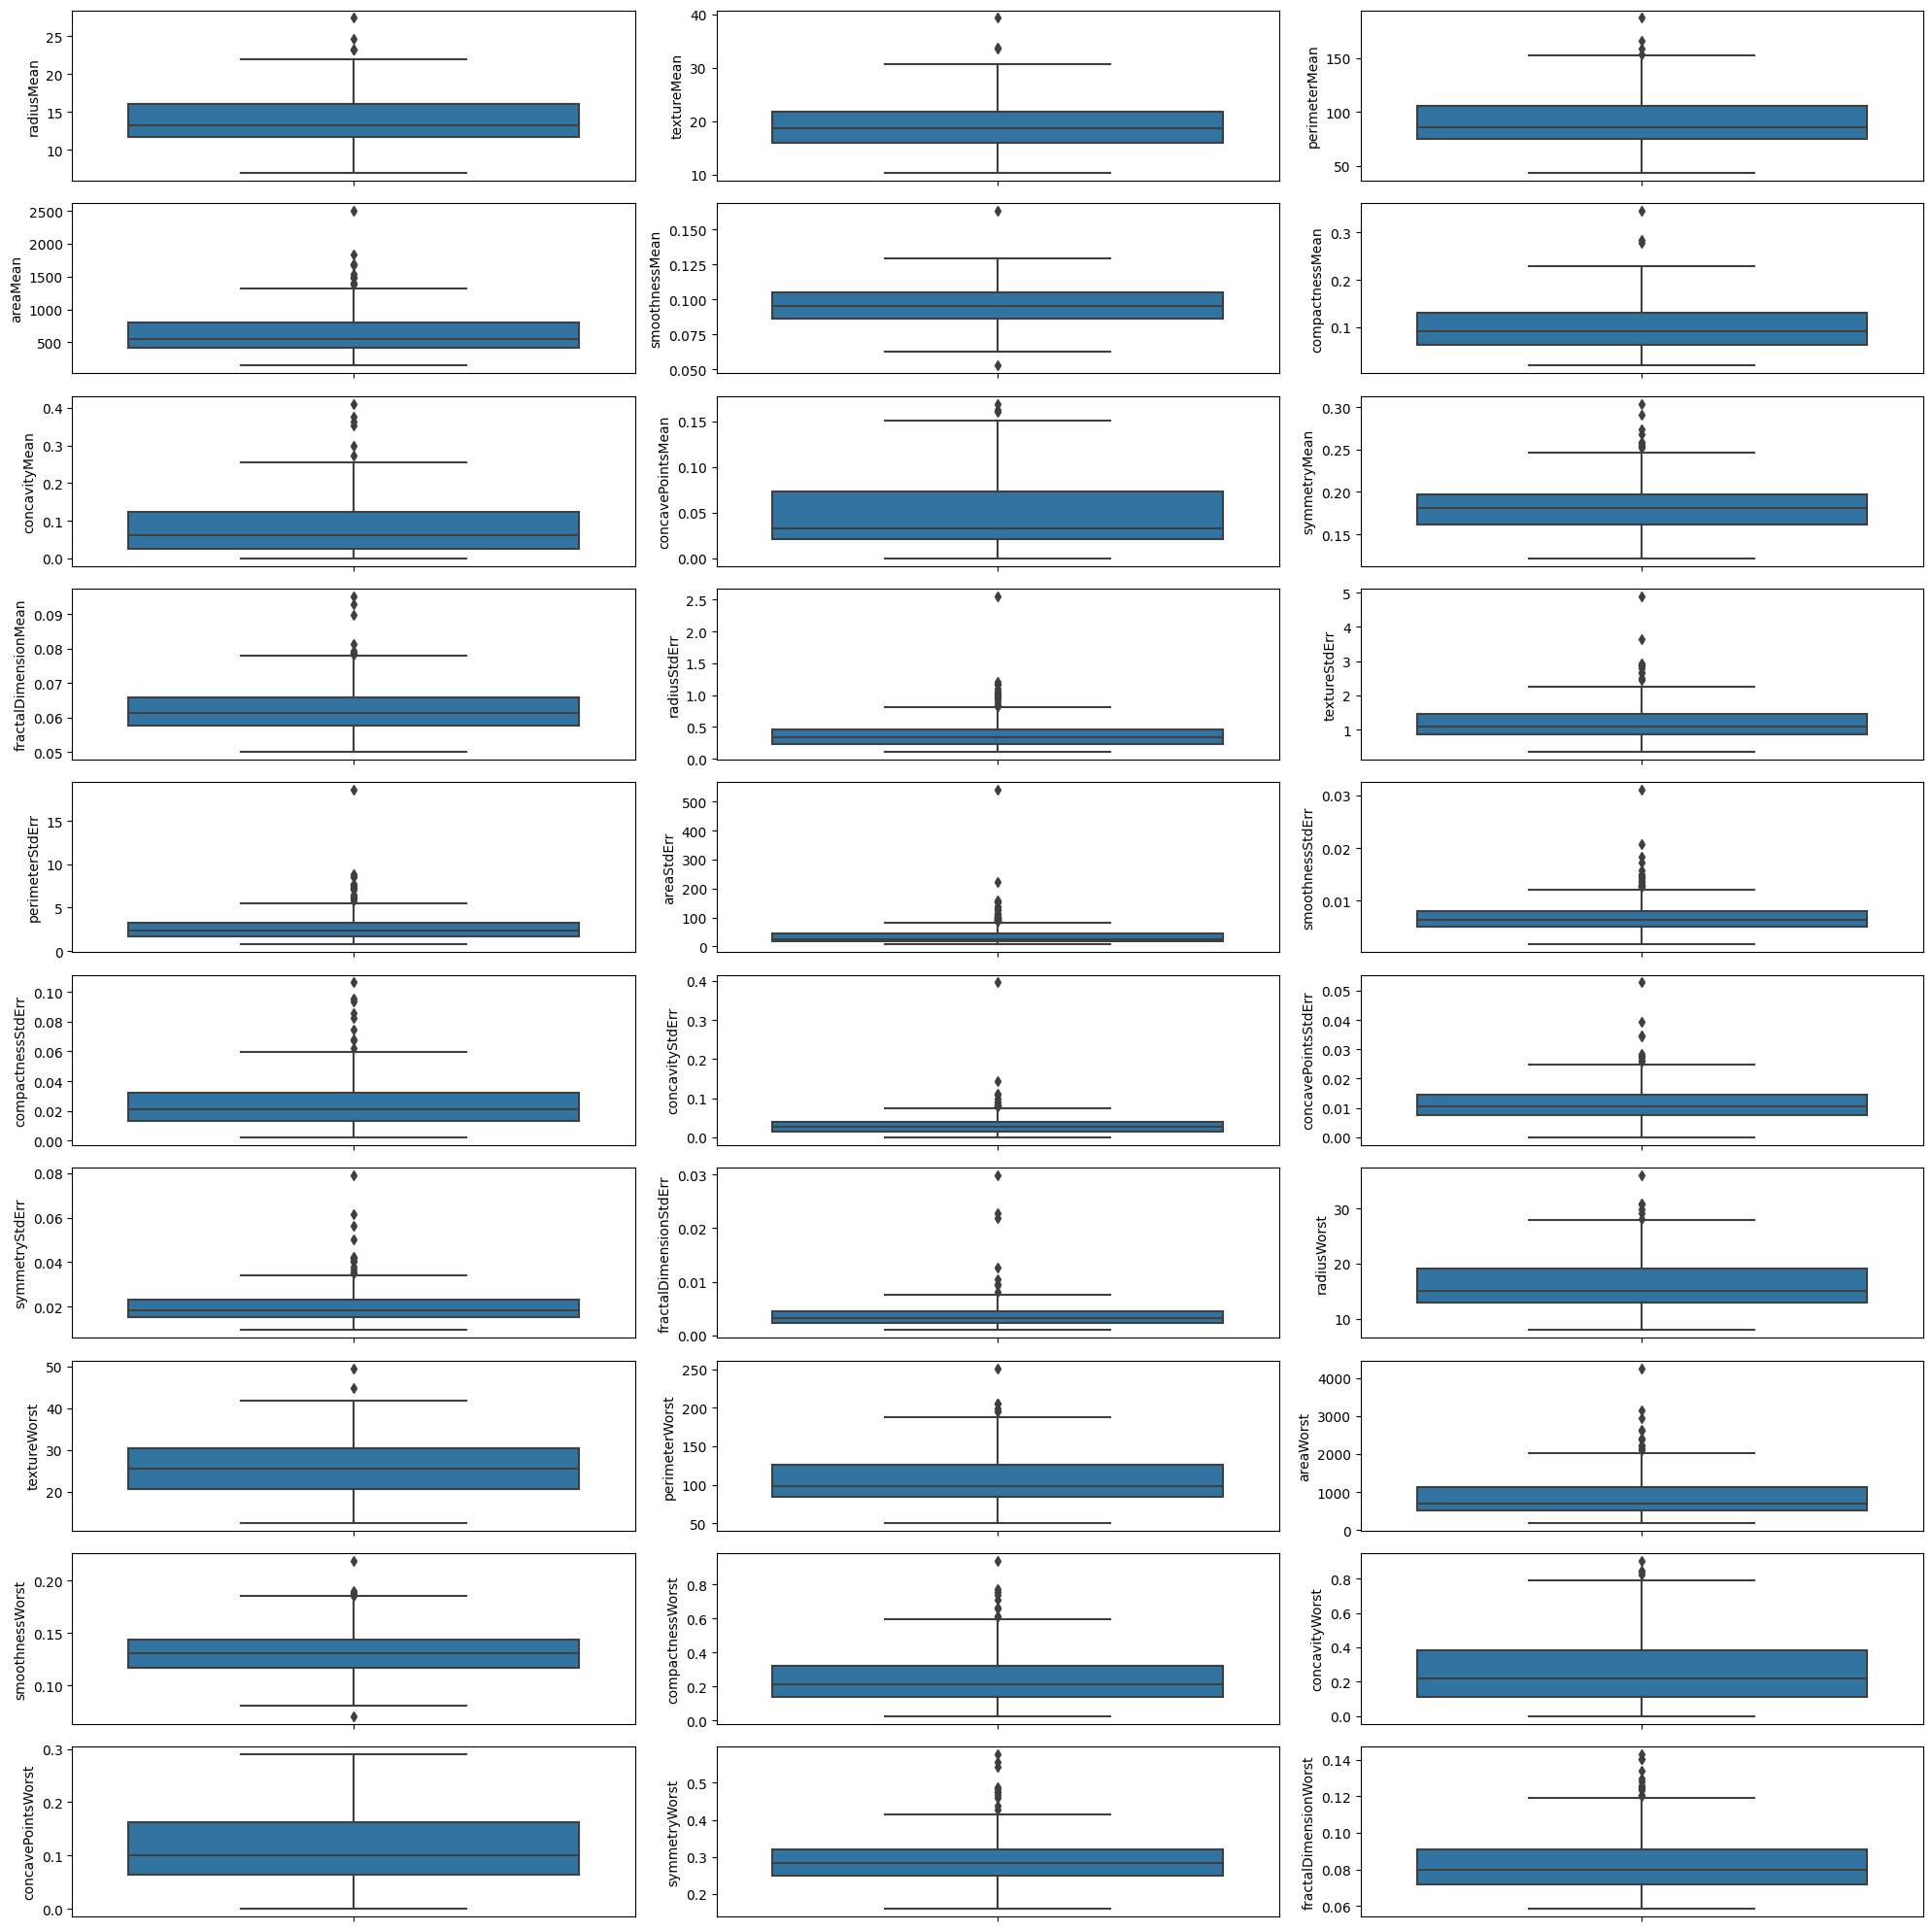

In [65]:
plot_box_grid(df=df_raw_labeled, subfigsize=(20,2))

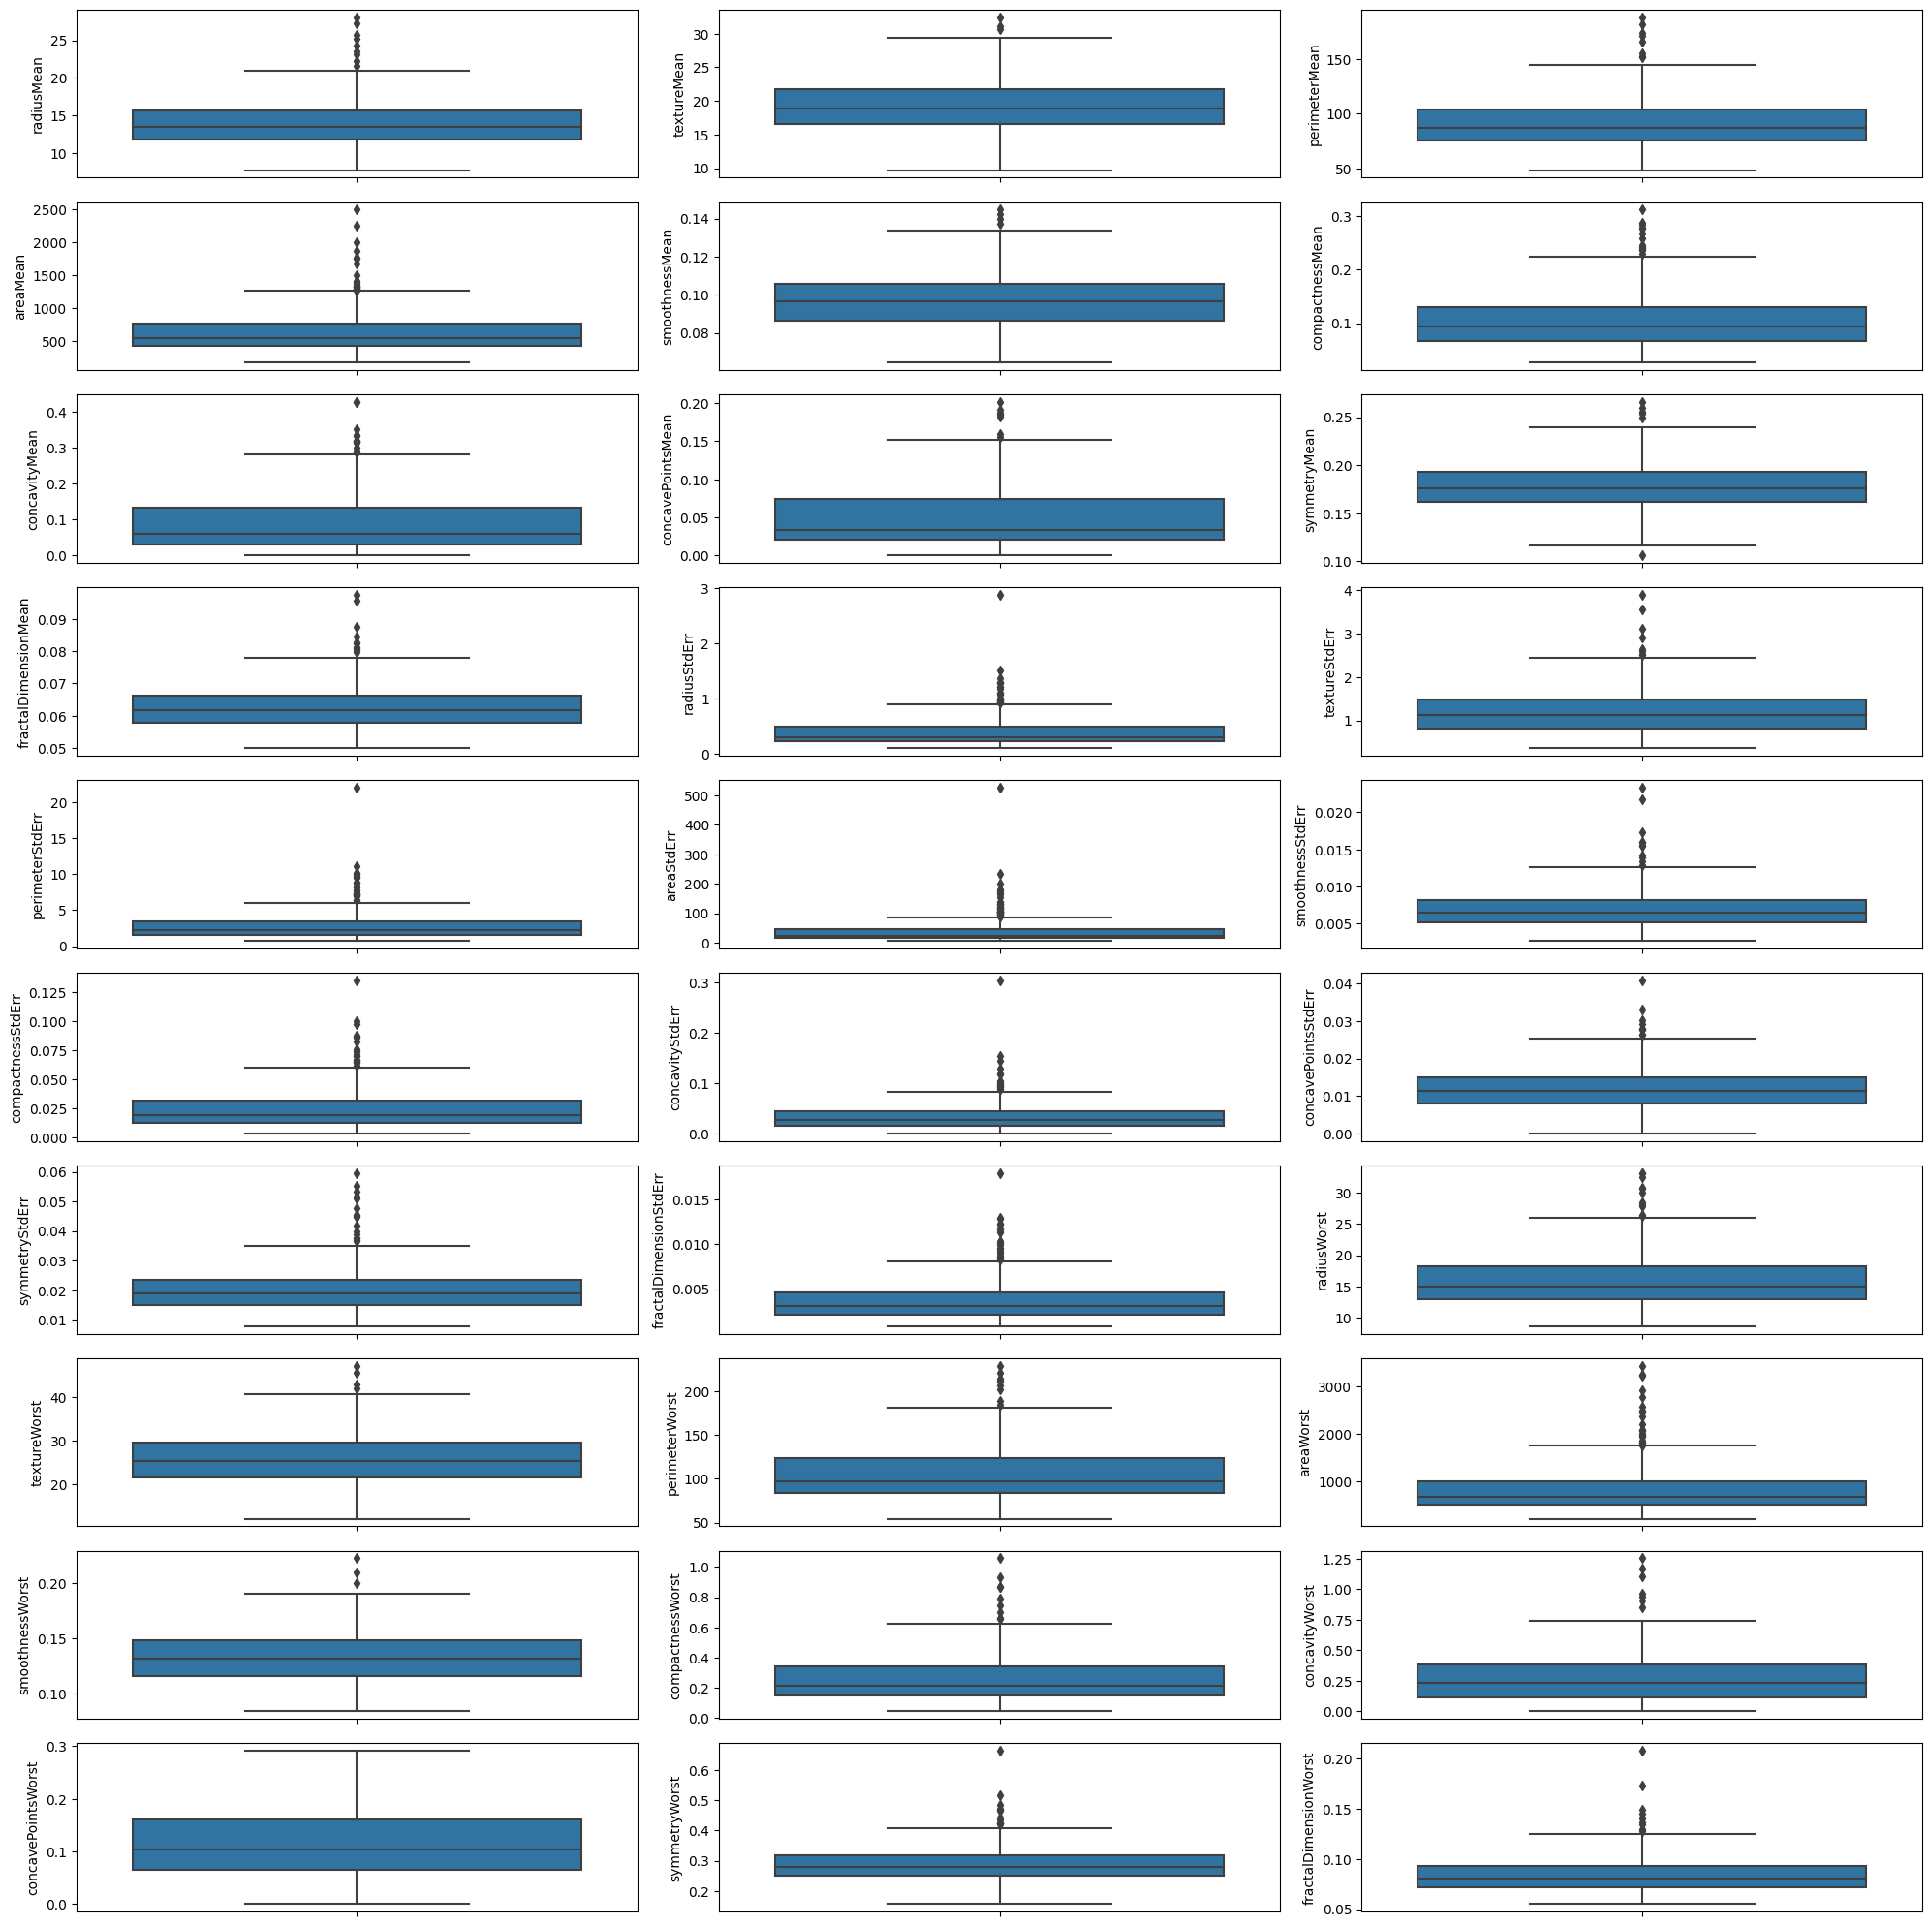

In [66]:
plot_box_grid(df=df_raw_test, subfigsize=(20,2))

concavePointsWorst does not have any IQR outliers.


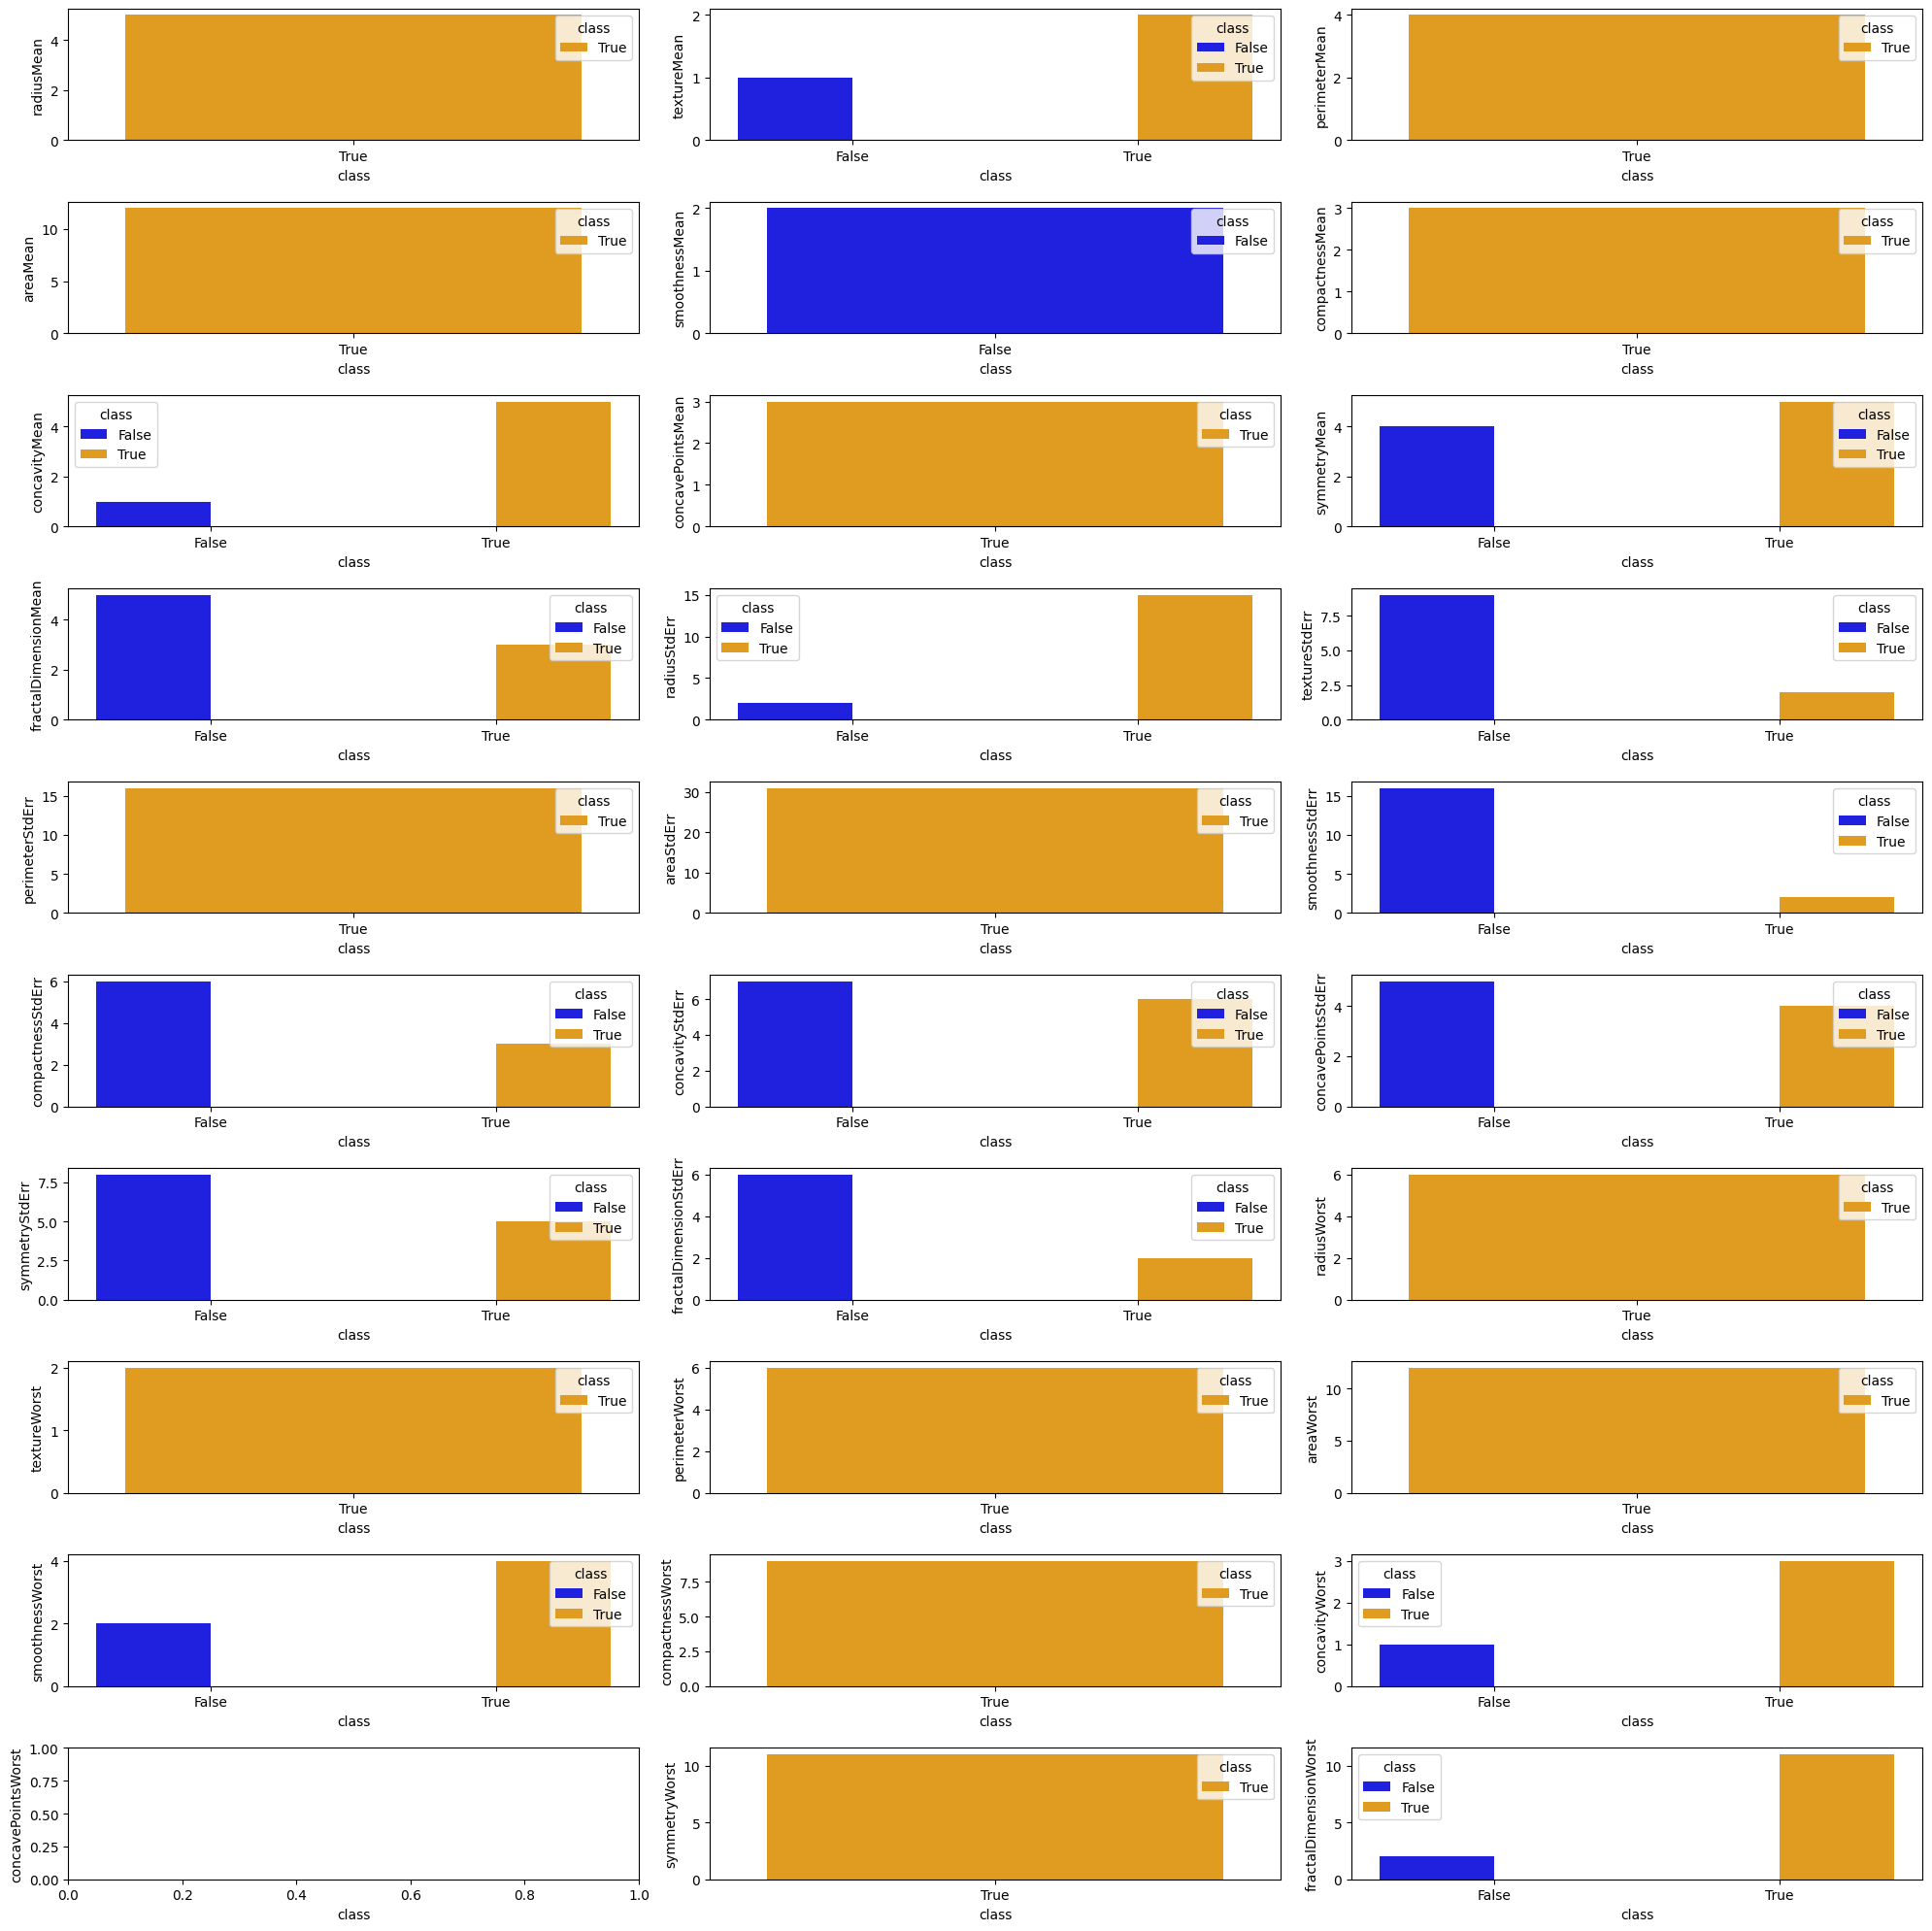

In [67]:
num_cols = get_numeric_feature_columns(df=df_raw_labeled)

ax = make_plot_grid_ax(num_cols=num_cols, plot_cols=3, subfigsize=(20, 2))
custom_palette = {True: "orange", False: "blue"}

for i, col in enumerate(num_cols):
    df_outliers = tag_iqr_outliers(df=df_raw_labeled, col=col)

    ax[i].set_ylabel(col)
    ax[i].set_xlabel("class")
    
    if df_outliers.shape[0] == 0:
        print(f"{col} does not have any IQR outliers.")
        continue

    df_outliers_grouped = df_outliers.groupby("class")[col].count().reset_index()
    sns.barplot(data=df_outliers_grouped, x="class", y=col, hue="class", ax=ax[i], palette=custom_palette)

plt.tight_layout()

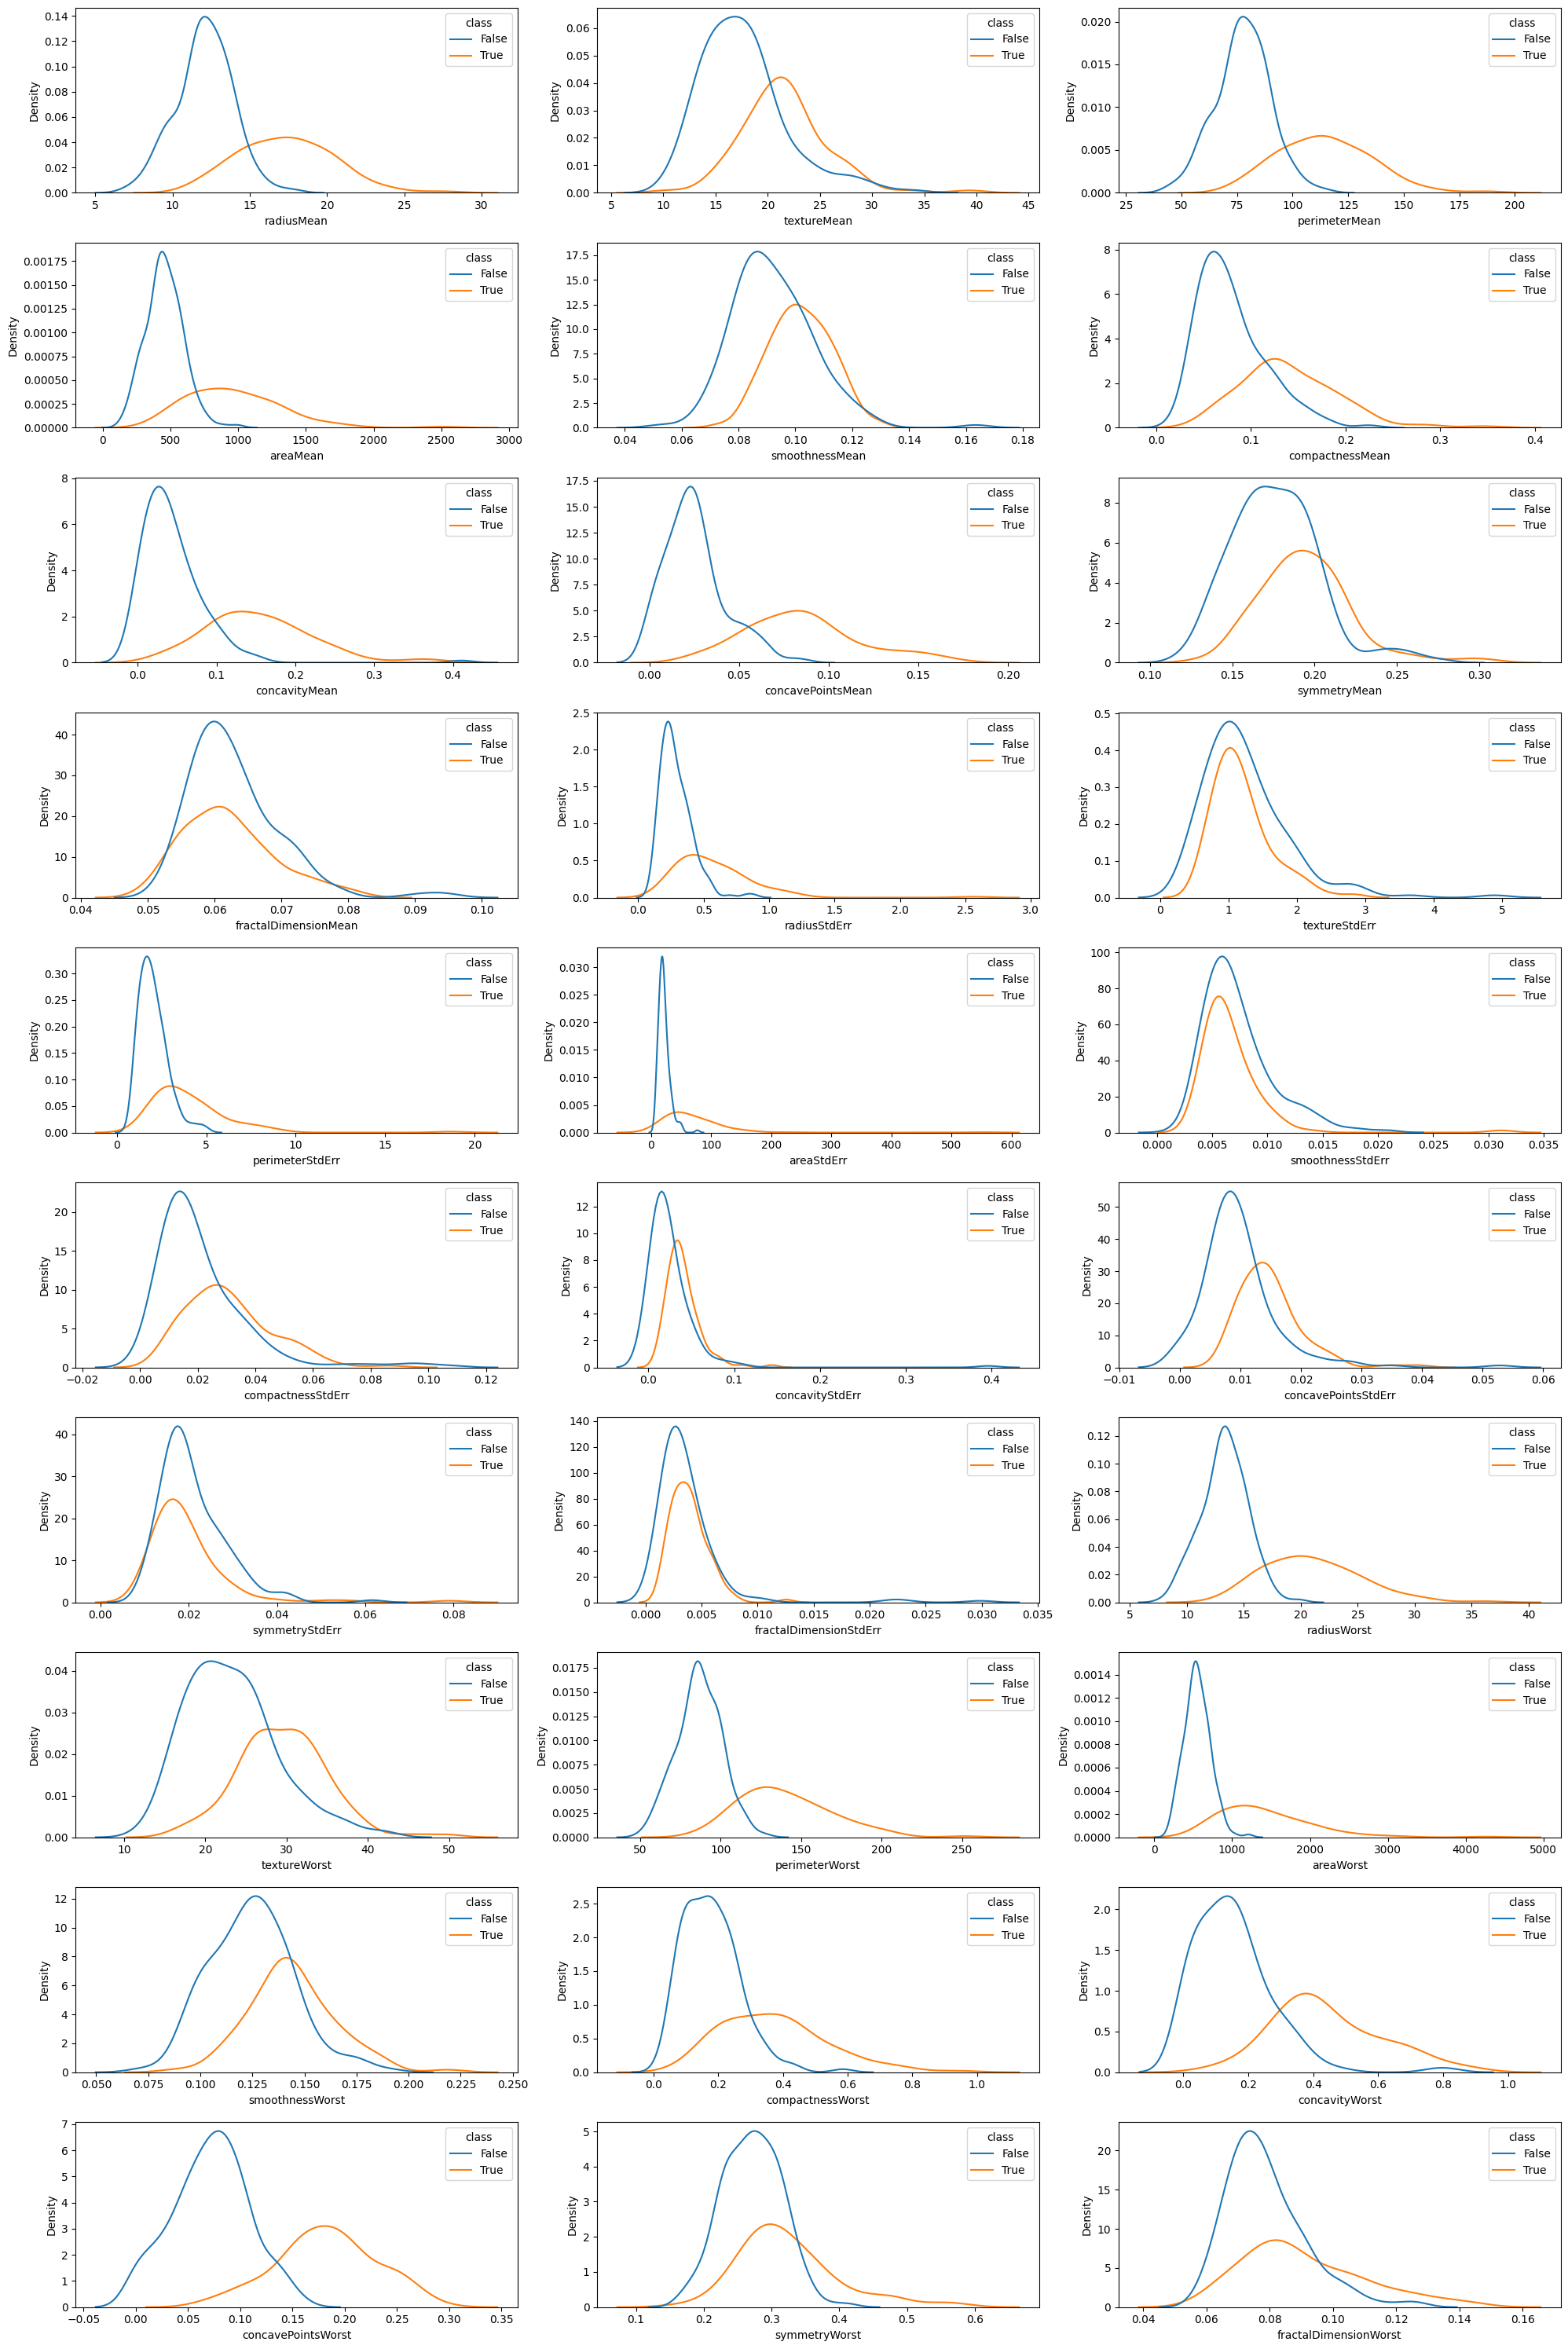

In [68]:
num_cols = df_raw_labeled.select_dtypes(include=np.number).drop(["class", "ID"], axis=1, errors="ignore").columns

plot_cols = 3
plot_rows = int(np.ceil((len(num_cols)/plot_cols)))

fig, ax = plt.subplots(plot_rows, plot_cols, figsize=(20, 3 * plot_rows))
ax = ax.flatten()

for i, col in enumerate(num_cols):
    sns.kdeplot(data=df_raw_labeled, x=col, hue="class", ax=ax[i])

plt.tight_layout()

In [69]:
df_raw_labeled

,ID,class,radiusMean,textureMean,perimeterMean,areaMean,smoothnessMean,compactnessMean,concavityMean,concavePointsMean,...,radiusWorst,textureWorst,perimeterWorst,areaWorst,smoothnessWorst,compactnessWorst,concavityWorst,concavePointsWorst,symmetryWorst,fractalDimensionWorst
0,8813129,False,13.27,17.02,84.55,546.4,0.08445,0.04994,0.03554,0.024560,...,15.14,23.60,98.84,708.8,0.1276,0.13110,0.17860,0.09678,0.2506,0.07623
1,898678,False,12.06,18.90,76.66,445.3,0.08386,0.05794,0.00751,0.008488,...,13.64,27.06,86.54,562.6,0.1289,0.13520,0.04506,0.05093,0.2880,0.08083
2,917896,False,13.71,18.68,88.73,571.0,0.09916,0.10700,0.05385,0.037830,...,15.11,25.63,99.43,701.9,0.1425,0.25660,0.19350,0.12840,0.2849,0.09031
3,869691,True,11.80,16.58,78.99,432.0,0.10910,0.17000,0.16590,0.074150,...,13.74,26.38,91.93,591.7,0.1385,0.40920,0.45040,0.18650,0.5774,0.10300
4,9110127,True,18.03,16.85,117.50,990.0,0.08947,0.12320,0.10900,0.062540,...,20.38,22.02,133.30,1292.0,0.1263,0.26660,0.42900,0.15350,0.2842,0.08225
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,89864002,False,11.71,15.45,75.03,420.3,0.11500,0.07281,0.04006,0.032500,...,13.06,18.16,84.16,516.4,0.1460,0.11150,0.10870,0.07864,0.2765,0.07806
281,884626,False,12.89,14.11,84.95,512.2,0.08760,0.13460,0.13740,0.039800,...,14.39,17.70,105.00,639.1,0.1254,0.58490,0.77270,0.15610,0.2639,0.11780
282,892189,True,11.76,18.14,75.00,431.1,0.09968,0.05914,0.02685,0.035150,...,13.36,23.39,85.10,553.6,0.1137,0.07974,0.06120,0.07160,0.1978,0.06915
283,919812,False,11.69,24.44,76.37,406.4,0.12360,0.15520,0.04515,0.045310,...,12.98,32.19,86.12,487.7,0.1768,0.32510,0.13950,0.13080,0.2803,0.09970


,class,radiusMean,textureMean,perimeterMean,areaMean,smoothnessMean,compactnessMean,concavityMean,concavePointsMean,symmetryMean,...,radiusWorst,textureWorst,perimeterWorst,areaWorst,smoothnessWorst,compactnessWorst,concavityWorst,concavePointsWorst,symmetryWorst,fractalDimensionWorst
class,1.000000,0.733513,0.422638,0.743500,0.714253,0.338718,0.575159,0.703754,0.777360,0.310818,...,0.773925,0.480592,0.778868,0.728420,0.423513,0.610757,0.700155,0.797757,0.410771,0.353929
radiusMean,0.733513,1.000000,0.336754,0.997917,0.986544,0.157545,0.526495,0.692159,0.831005,0.147605,...,0.974413,0.322692,0.969640,0.942497,0.124178,0.465992,0.589395,0.764128,0.180391,0.068976
textureMean,0.422638,0.336754,1.000000,0.338787,0.340337,-0.036714,0.184018,0.283089,0.283337,0.030440,...,0.353912,0.914263,0.351458,0.341271,0.066600,0.237557,0.275313,0.283469,0.075230,0.090605
perimeterMean,0.743500,0.997917,0.338787,1.000000,0.985754,0.193513,0.575284,0.728648,0.857191,0.181300,...,0.974166,0.322993,0.974502,0.943047,0.153852,0.506355,0.623724,0.788742,0.206029,0.110896
areaMean,0.714253,0.986544,0.340337,0.985754,1.000000,0.155572,0.513626,0.696621,0.827718,0.153239,...,0.971577,0.317193,0.967910,0.968140,0.122962,0.438938,0.573028,0.742453,0.166343,0.063602
smoothnessMean,0.338718,0.157545,-0.036714,0.193513,0.155572,1.000000,0.665439,0.501771,0.524537,0.529569,...,0.196356,0.008522,0.222485,0.187081,0.785954,0.484920,0.433230,0.491921,0.349646,0.548192
compactnessMean,0.575159,0.526495,0.184018,0.575284,0.513626,0.665439,1.000000,0.858225,0.825393,0.579121,...,0.548862,0.172100,0.601120,0.520672,0.550688,0.868691,0.805003,0.805963,0.485307,0.695301
concavityMean,0.703754,0.692159,0.283089,0.728648,0.696621,0.501771,0.858225,1.000000,0.922635,0.483202,...,0.702417,0.272084,0.739587,0.686870,0.437050,0.750444,0.895382,0.867424,0.402834,0.522903
concavePointsMean,0.777360,0.831005,0.283337,0.857191,0.827718,0.524537,0.825393,0.922635,1.000000,0.457467,...,0.841025,0.280224,0.863650,0.815525,0.436364,0.690820,0.788481,0.922212,0.390682,0.401448
symmetryMean,0.310818,0.147605,0.030440,0.181300,0.153239,0.529569,0.579121,0.483202,0.457467,1.000000,...,0.178175,0.023585,0.208420,0.174939,0.367985,0.432511,0.392932,0.399444,0.705212,0.416952


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


<Axes: >

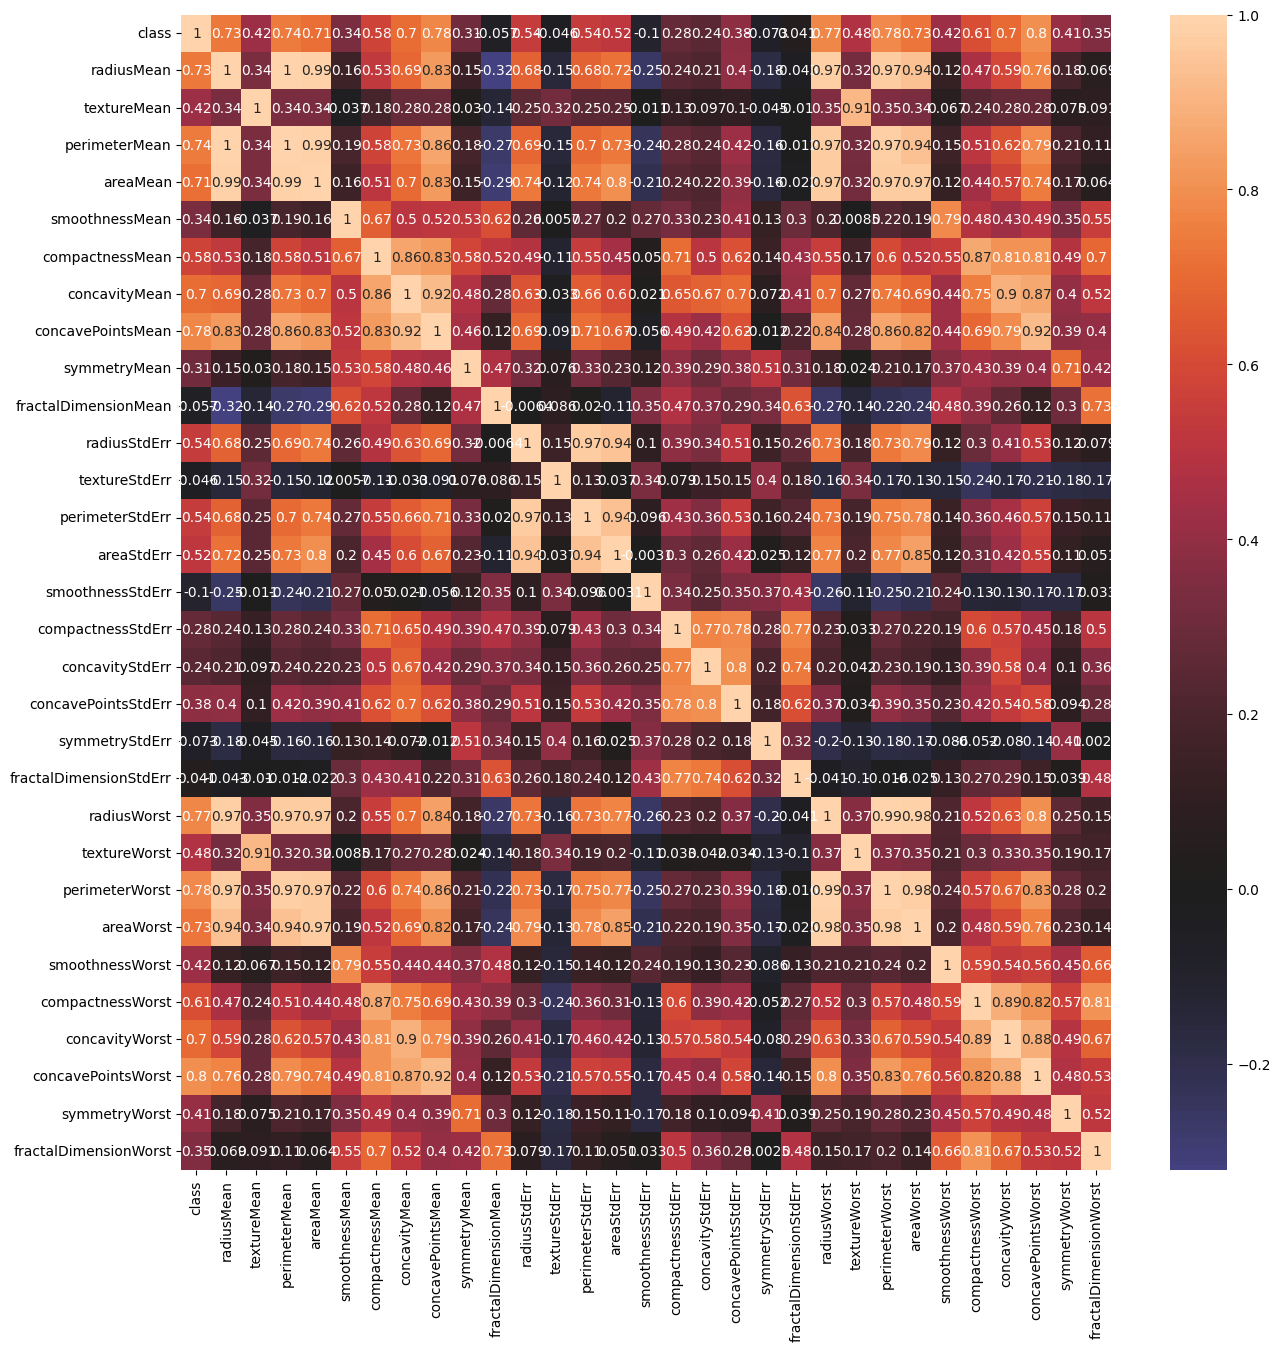

In [70]:
df_corr = df_raw_labeled.copy()
df_corr["class"] = df_corr["class"].astype(int)
df_corr = df_corr.select_dtypes(include=np.number).drop(["ID"], axis=1, errors="ignore").corr()
display(df_corr)

plt.figure(figsize=(15,15))
sns.heatmap(df_corr, annot=True, center=0.0)

## Modeling

In [71]:
def train_test_split_print(df: pd.DataFrame, train_pct: float = 0.7, seed: int = 42) -> tuple:
    df_train, df_test = train_test_split(df, train_size=train_pct, random_state=seed, shuffle=True)

    print(f"Train rows: {df_train.shape[0]}")
    print(f"Test rows: {df_test.shape[0]}")

    return df_train, df_test


def get_X_y(df: pd.DataFrame, lbl_col: str) -> tuple:
    X = df[[c for c in df.columns if c != lbl_col]].drop("ID", axis=1)
    y = df[lbl_col]

    return X, y


def print_prfs(prfs: list, label: str) -> None:
    display(pd.DataFrame({
        f"{label} Precision": [prfs[0]], 
        f"{label} Recall": [prfs[1]], 
        f"{label} F1": [prfs[2]], 
    }))

def display_train_test_confusion_matrix(y_train: np.array, y_test: np.array, train_y_pred: np.array, test_y_pred: np.array) -> None:
    cm_train = confusion_matrix(y_train, train_y_pred)
    cm_test = confusion_matrix(y_test, test_y_pred)
    
    fig, ax = plt.subplots(1,2, figsize=(12, 6))
    
    cm_train_display = ConfusionMatrixDisplay(cm_train)
    cm_train_display.plot(ax=ax[0])
    
    cm_test_display = ConfusionMatrixDisplay(cm_test)
    cm_test_display.plot(ax=ax[1])
    
    ax[0].title.set_text("Train Confusion Matrix")
    ax[1].title.set_text("Test Confusion Matrix")
    
    plt.tight_layout()

def prepare_cv_datasets(df: pd.DataFrame, cv_seeds: list = [1, 7, 42, 100, 120], lbl_col: str = "class"):
    train_cv_dfs = []
    test_cv_dfs = []

    for seed in cv_seeds:
        # Split dataset into train and test
        df_train, df_test = train_test_split_print(df=df, train_pct=0.7, seed=seed)

        # Separate the features from the label
        X_train, y_train = get_X_y(df=df_train, lbl_col=lbl_col)
        X_test, y_test = get_X_y(df=df_test, lbl_col=lbl_col)

        # Uncomment only if DF has categorical, which in this case it doesn't
        #cat_cols = []
        #X_train_num = X_train[[c for c in X_train.columns if c not in cat_cols]]
        #X_test_num = X_test[[c for c in X_test.columns if c not in cat_cols]]

        ## Encode the categoricals, by fitting on the training split and then applying over the testing split
        #one_hot_enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop="first")
        #X_train_enc = one_hot_enc.fit_transform(X_train[cat_cols]) 
        #X_test_enc = one_hot_enc.transform(X_test[cat_cols])

        # We rejoin the numeric and categorical encoded columns
        #X_train = np.hstack((X_train_num, X_train_enc))
        #X_test = np.hstack((X_test_num, X_test_enc))

        # Scale data to make it more efficient
        scaler = StandardScaler()
        scaler.fit(X_train)
        
        X_train = scaler.transform(X_train)
        X_test = scaler.transform(X_test)

        # Generate 
        train_cv_dfs.append((X_train, y_train))
        test_cv_dfs.append((X_test, y_test))
        
    return train_cv_dfs, test_cv_dfs

In [72]:
cv_seeds=[0, 1, 7, 42, 100, 120, 123, 666, 999, 100000]
train_cv_dfs, test_cv_dfs = prepare_cv_datasets(df=df_raw_labeled, cv_seeds=cv_seeds, lbl_col="class")

Train rows: 199
Test rows: 86
Train rows: 199
Test rows: 86
Train rows: 199
Test rows: 86
Train rows: 199
Test rows: 86
Train rows: 199
Test rows: 86
Train rows: 199
Test rows: 86
Train rows: 199
Test rows: 86
Train rows: 199
Test rows: 86
Train rows: 199
Test rows: 86
Train rows: 199
Test rows: 86


### LogisticRegression

In [73]:
step = "Baseline"

In [74]:
METRICS["LogisticRegression"] = {}

,Training Precision,Training Recall,Training F1
0,0.992809,0.988081,0.990336


,Test Precision,Test Recall,Test F1
0,0.95901,0.959282,0.958706


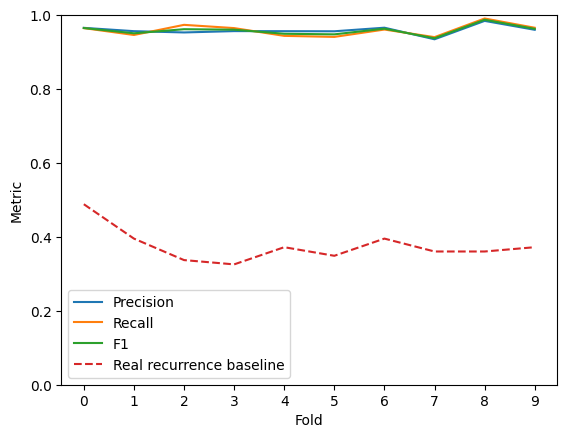

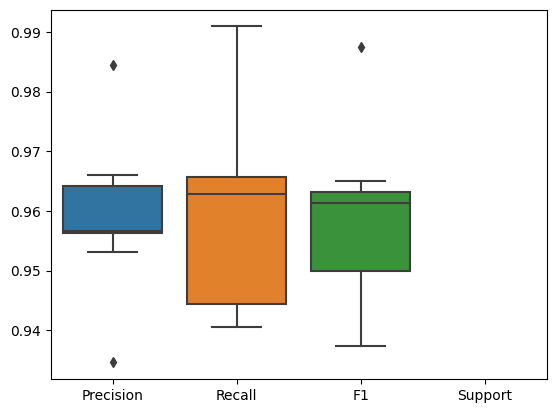

In [75]:
train_prfs_arr = np.empty((len(cv_seeds), 4))
test_prfs_arr = np.empty((len(cv_seeds), 4))

proportion_lbls_test = np.empty((len(cv_seeds)))

for idx, fold in enumerate(zip(train_cv_dfs, test_cv_dfs)):
    X_train, y_train = fold[0]
    X_test, y_test = fold[1]

    proportion_lbls_test[idx] = y_test.sum() / y_test.count() 
    
    logistic_reg = LogisticRegression(random_state=42)
    logistic_reg.fit(X_train, y_train)
    
    train_y_pred = logistic_reg.predict(X_train)
    test_y_pred = logistic_reg.predict(X_test)
    
    #display_train_test_confusion_matrix(y_train=y_train, y_test=y_test, train_y_pred=train_y_pred, test_y_pred=test_y_pred)
    
    train_prfs = precision_recall_fscore_support(y_train, train_y_pred, average='macro')
    test_prfs = precision_recall_fscore_support(y_test, test_y_pred, average='macro')

    train_prfs_arr[idx] = train_prfs
    test_prfs_arr[idx] = test_prfs

plt.plot(test_prfs_arr[:, 0], label="Precision")
plt.plot(test_prfs_arr[:, 1], label="Recall")
plt.plot(test_prfs_arr[:, 2], label="F1")
plt.xticks(range(test_prfs_arr.shape[0]))
plt.ylabel("Metric")
plt.xlabel("Fold")
plt.ylim(0.0, 1.0)
plt.plot(proportion_lbls_test, label="Real recurrence baseline", linestyle="--")
plt.legend()

train_cv_prfs = train_prfs_arr.mean(axis=0)
test_cv_prfs = test_prfs_arr.mean(axis=0)

print_prfs(prfs=train_cv_prfs, label="Training")
print_prfs(prfs=test_cv_prfs, label="Test")

plt.figure()
sns.boxplot(test_prfs_arr)
ticks = plt.xticks()[0]
plt.xticks(ticks=ticks, labels=["Precision", "Recall", "F1", "Support"])
#plt.ylim(0.0, 1.0)

METRICS["LogisticRegression"][step] = {}
METRICS["LogisticRegression"][step]["train"] = tuple(train_cv_prfs)
METRICS["LogisticRegression"][step]["test"] = tuple(test_cv_prfs)

### Xgboost

In [76]:
METRICS["XGBClassifier"] = {}

,Training Precision,Training Recall,Training F1
0,1.0,1.0,1.0


,Test Precision,Test Recall,Test F1
0,0.935794,0.940533,0.935685


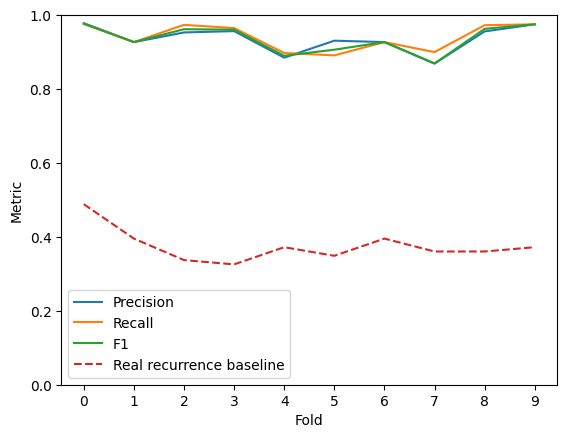

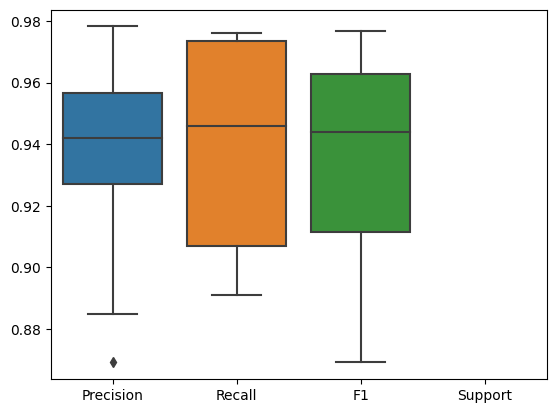

In [77]:
train_prfs_arr = np.empty((len(cv_seeds), 4))
test_prfs_arr = np.empty((len(cv_seeds), 4))

proportion_lbls_test = np.empty((len(cv_seeds)))

for idx, fold in enumerate(zip(train_cv_dfs, test_cv_dfs)):
    X_train, y_train = fold[0]
    X_test, y_test = fold[1]

    proportion_lbls_test[idx] = y_test.sum() / y_test.count() 
    
    xgbc_baseline = XGBClassifier(random_state=42)
    xgbc_baseline.fit(X_train, y_train)
    
    train_y_pred = xgbc_baseline.predict(X_train)
    test_y_pred = xgbc_baseline.predict(X_test)
    
    #display_train_test_confusion_matrix(y_train=y_train, y_test=y_test, train_y_pred=train_y_pred, test_y_pred=test_y_pred)
    
    train_prfs = precision_recall_fscore_support(y_train, train_y_pred, average='macro')
    test_prfs = precision_recall_fscore_support(y_test, test_y_pred, average='macro')

    train_prfs_arr[idx] = train_prfs
    test_prfs_arr[idx] = test_prfs

plt.plot(test_prfs_arr[:, 0], label="Precision")
plt.plot(test_prfs_arr[:, 1], label="Recall")
plt.plot(test_prfs_arr[:, 2], label="F1")
plt.xticks(range(test_prfs_arr.shape[0]))
plt.ylabel("Metric")
plt.xlabel("Fold")
plt.ylim(0.0, 1.0)
plt.plot(proportion_lbls_test, label="Real recurrence baseline", linestyle="--")
plt.legend()

train_cv_prfs = train_prfs_arr.mean(axis=0)
test_cv_prfs = test_prfs_arr.mean(axis=0)

print_prfs(prfs=train_cv_prfs, label="Training")
print_prfs(prfs=test_cv_prfs, label="Test")

plt.figure()
sns.boxplot(test_prfs_arr)
ticks = plt.xticks()[0]
plt.xticks(ticks=ticks, labels=["Precision", "Recall", "F1", "Support"])
#plt.ylim(0.0, 1.0)

METRICS["XGBClassifier"][step] = {}
METRICS["XGBClassifier"][step]["train"] = tuple(train_cv_prfs)
METRICS["XGBClassifier"][step]["test"] = tuple(test_cv_prfs)

### SVM

In [79]:
METRICS["SVM"] = {}

,Training Precision,Training Recall,Training F1
0,0.986398,0.98157,0.983855


,Test Precision,Test Recall,Test F1
0,0.968281,0.959726,0.963319


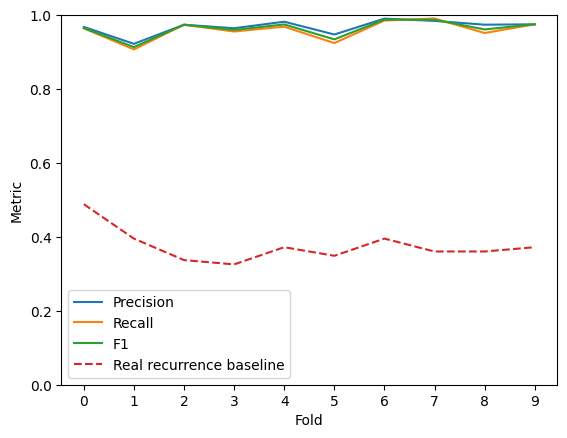

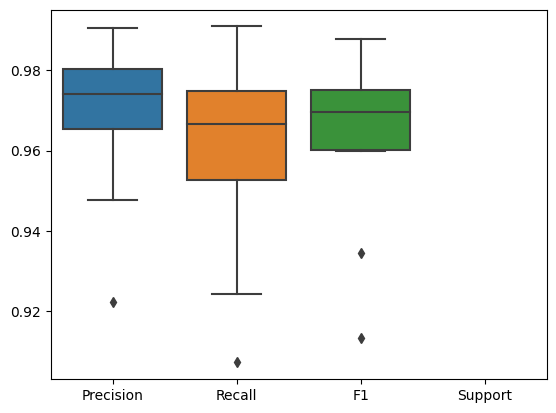

In [80]:
train_prfs_arr = np.empty((len(cv_seeds), 4))
test_prfs_arr = np.empty((len(cv_seeds), 4))

proportion_lbls_test = np.empty((len(cv_seeds)))

for idx, fold in enumerate(zip(train_cv_dfs, test_cv_dfs)):
    X_train, y_train = fold[0]
    X_test, y_test = fold[1]

    proportion_lbls_test[idx] = y_test.sum() / y_test.count() 
    
    clf = svm.SVC(random_state=42)
    clf.fit(X_train, y_train)
    
    train_y_pred = clf.predict(X_train)
    test_y_pred = clf.predict(X_test)
    
    #display_train_test_confusion_matrix(y_train=y_train, y_test=y_test, train_y_pred=train_y_pred, test_y_pred=test_y_pred)
    
    train_prfs = precision_recall_fscore_support(y_train, train_y_pred, average='macro')
    test_prfs = precision_recall_fscore_support(y_test, test_y_pred, average='macro')

    train_prfs_arr[idx] = train_prfs
    test_prfs_arr[idx] = test_prfs
plt.plot(test_prfs_arr[:, 0], label="Precision")
plt.plot(test_prfs_arr[:, 1], label="Recall")
plt.plot(test_prfs_arr[:, 2], label="F1")
plt.xticks(range(test_prfs_arr.shape[0]))
plt.ylabel("Metric")
plt.xlabel("Fold")
plt.ylim(0.0, 1.0)
plt.plot(proportion_lbls_test, label="Real recurrence baseline", linestyle="--")
plt.legend()

train_cv_prfs = train_prfs_arr.mean(axis=0)
test_cv_prfs = test_prfs_arr.mean(axis=0)

print_prfs(prfs=train_cv_prfs, label="Training")
print_prfs(prfs=test_cv_prfs, label="Test")

plt.figure()
sns.boxplot(test_prfs_arr)
ticks = plt.xticks()[0]
plt.xticks(ticks=ticks, labels=["Precision", "Recall", "F1", "Support"])
#plt.ylim(0.0, 1.0)

METRICS["SVM"][step] = {}
METRICS["SVM"][step]["train"] = tuple(train_cv_prfs)
METRICS["SVM"][step]["test"] = tuple(test_cv_prfs)

## Metrics so far

(0.9590103646062971, 0.9592824297104077, 0.9587062005225739, nan)
(0.9357942913750528, 0.9405332449223236, 0.935685310919876, nan)
(0.9682812259267172, 0.9597263863213333, 0.9633185681058386, nan)


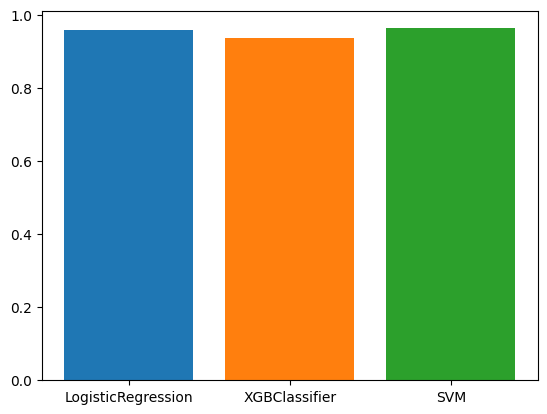

In [81]:
for k,v in METRICS.items():
    print(v[step]["test"])

    plt.bar(x=k, height=v[step]["test"][2])

In [82]:
print(json.dumps(METRICS, indent=4))

{
    "LogisticRegression": {
        "Baseline": {
            "train": [
                0.9928094003905628,
                0.9880805355747061,
                0.9903358587689869,
                NaN
            ],
            "test": [
                0.9590103646062971,
                0.9592824297104077,
                0.9587062005225739,
                NaN
            ]
        }
    },
    "XGBClassifier": {
        "Baseline": {
            "train": [
                1.0,
                1.0,
                1.0,
                NaN
            ],
            "test": [
                0.9357942913750528,
                0.9405332449223236,
                0.935685310919876,
                NaN
            ]
        }
    },
    "SVM": {
        "Baseline": {
            "train": [
                0.9863979719070229,
                0.9815695078816835,
                0.9838551969865614,
                NaN
            ],
            "test": [
                0.96828122592671

## Final Baseline Model

In [83]:
X_train, y_train = get_X_y(df_raw_labeled, lbl_col="class")
X_test = df_raw_test.drop("ID", axis=1)

scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

logistic_reg = LogisticRegression(random_state=42)
logistic_reg.fit(X_train, y_train)

train_y_pred = logistic_reg.predict(X_train)
test_y_pred = logistic_reg.predict(X_test)

train_prfs = precision_recall_fscore_support(y_train, train_y_pred, average='macro')
train_prfs

(0.994413407821229, 0.9907407407407407, 0.9925181140396935, None)

In [84]:
submission_dt = dt.datetime.now().strftime("%Y%m%d_%H%M%S")

submission = pd.DataFrame({"ID": df_raw_test["ID"], "class": test_y_pred})
submission = submission.replace({False: "false", True: "true"})
submission 

save_path = "submissions/baseline"
sub = "."
for part in save_path.split("/"):
    sub = sub + "/" + part 
    try:
        os.mkdir(sub)
        print(f"Created path {sub}")
    except FileExistsError:
        print(f"Path {sub} already exists.")
        pass

submission.to_csv(f"{save_path}/submission_{submission_dt}.csv", index=False)

Path ./submissions already exists.
Path ./submissions/baseline already exists.


In [85]:
submission.groupby("class").count()

,ID
class,
false,183
true,101


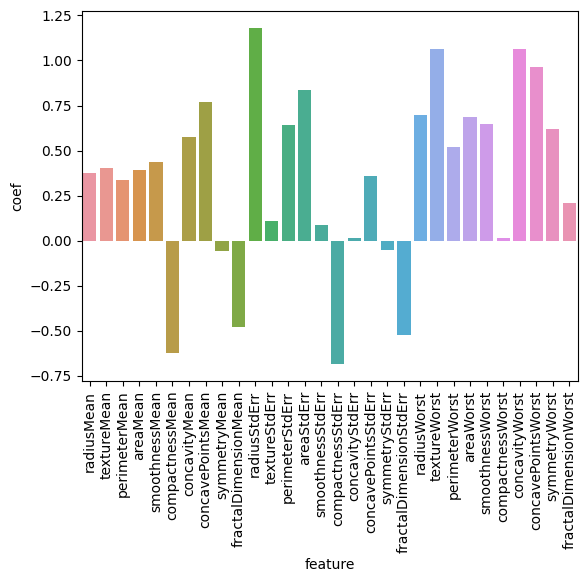

In [86]:
df_logreg_importance = pd.DataFrame({"feature": df_raw_test.drop("ID", axis=1).columns, "coef": logistic_reg.coef_[0]})

sns.barplot(data=df_logreg_importance, x="feature", y="coef")
plt.xticks(rotation=90);

# Second Iteration

## Feature Engineering

In [87]:
df_raw_labeled.columns

Index(['ID', 'class', 'radiusMean', 'textureMean', 'perimeterMean', 'areaMean',
       'smoothnessMean', 'compactnessMean', 'concavityMean',
       'concavePointsMean', 'symmetryMean', 'fractalDimensionMean',
       'radiusStdErr', 'textureStdErr', 'perimeterStdErr', 'areaStdErr',
       'smoothnessStdErr', 'compactnessStdErr', 'concavityStdErr',
       'concavePointsStdErr', 'symmetryStdErr', 'fractalDimensionStdErr',
       'radiusWorst', 'textureWorst', 'perimeterWorst', 'areaWorst',
       'smoothnessWorst', 'compactnessWorst', 'concavityWorst',
       'concavePointsWorst', 'symmetryWorst', 'fractalDimensionWorst'],
      dtype='object')

In [88]:
new_cols_train = []
new_cols_test = []

cols_created = []

# Extract columns first because otherwise we will be iterating over newly created columns
start_cols1 = list(sorted(df_raw_labeled.columns[2:]))
start_cols2 = start_cols1[1:]

for col1 in start_cols1:
    for col2 in start_cols2:
        if col1 == col2:
            continue

        if f"{col2}_by_{col1}" in cols_created:
            continue
        
        out_col = f"{col1}_by_{col2}"

        print(f"Creating {out_col}")
        cols_created.append(out_col)

        new_cols_train.append((col1, col2, out_col, df_raw_labeled[col1] * (df_raw_labeled[col2])))
        new_cols_test.append((col1, col2, out_col, df_raw_test[col1] * (df_raw_test[col2])))

Creating areaMean_by_areaStdErr
Creating areaMean_by_areaWorst
Creating areaMean_by_compactnessMean
Creating areaMean_by_compactnessStdErr
Creating areaMean_by_compactnessWorst
Creating areaMean_by_concavePointsMean
Creating areaMean_by_concavePointsStdErr
Creating areaMean_by_concavePointsWorst
Creating areaMean_by_concavityMean
Creating areaMean_by_concavityStdErr
Creating areaMean_by_concavityWorst
Creating areaMean_by_fractalDimensionMean
Creating areaMean_by_fractalDimensionStdErr
Creating areaMean_by_fractalDimensionWorst
Creating areaMean_by_perimeterMean
Creating areaMean_by_perimeterStdErr
Creating areaMean_by_perimeterWorst
Creating areaMean_by_radiusMean
Creating areaMean_by_radiusStdErr
Creating areaMean_by_radiusWorst
Creating areaMean_by_smoothnessMean
Creating areaMean_by_smoothnessStdErr
Creating areaMean_by_smoothnessWorst
Creating areaMean_by_symmetryMean
Creating areaMean_by_symmetryStdErr
Creating areaMean_by_symmetryWorst
Creating areaMean_by_textureMean
Creating a

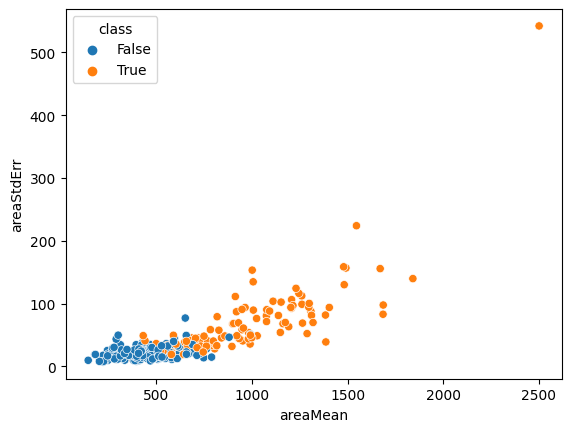

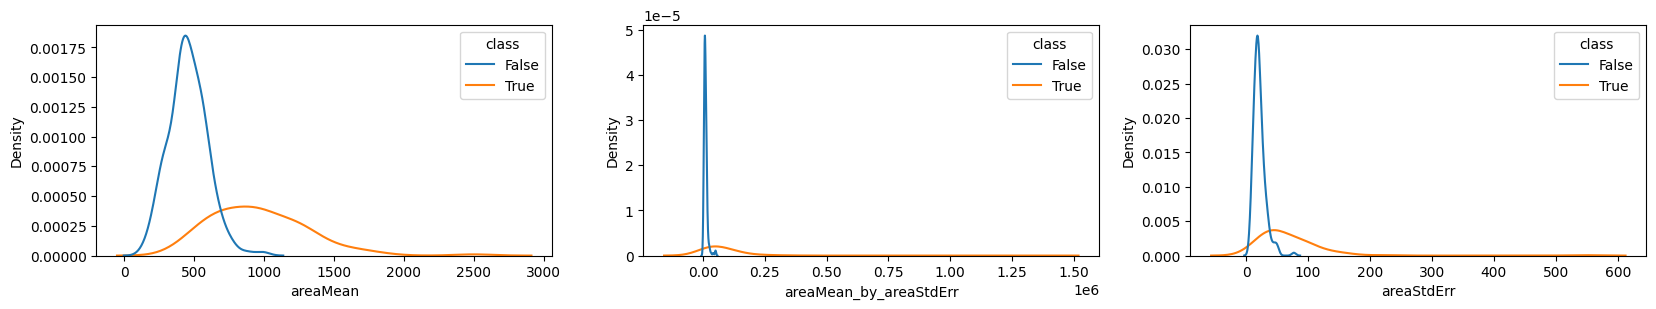

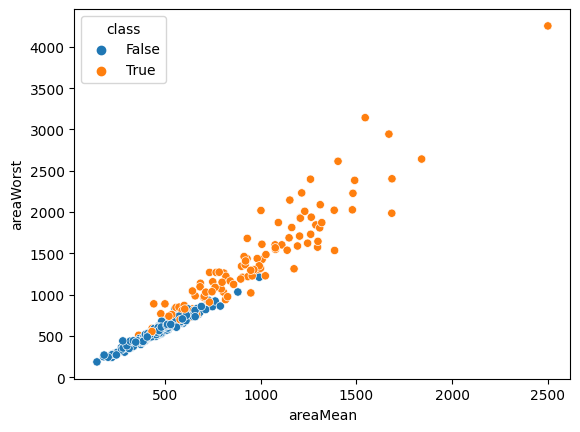

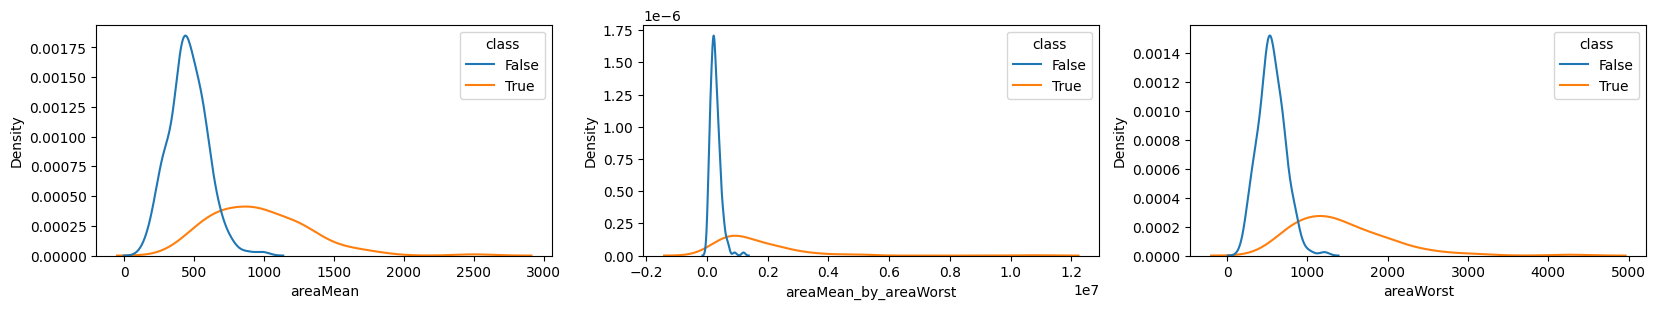

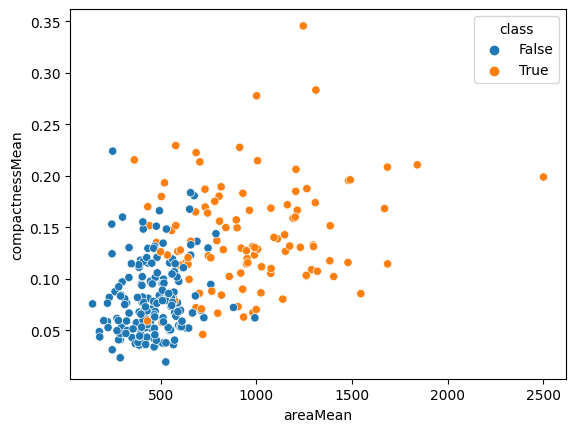

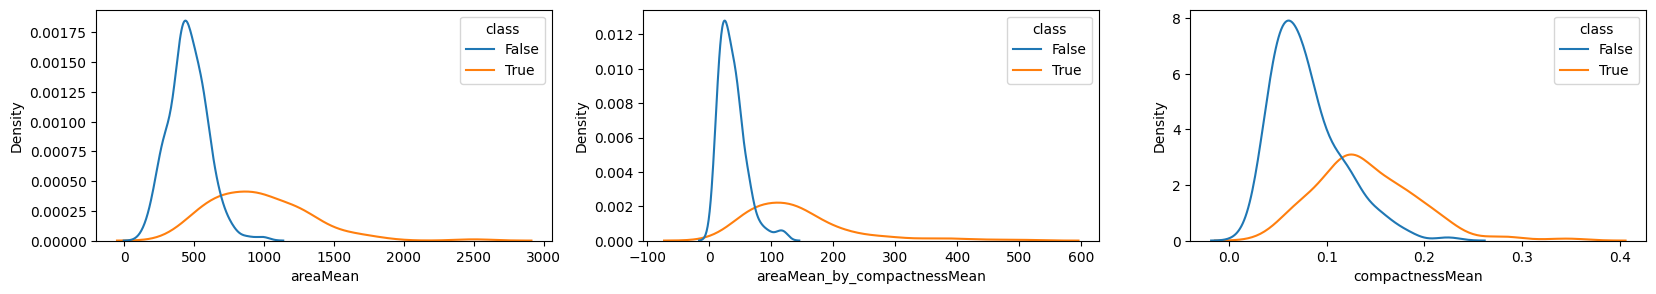

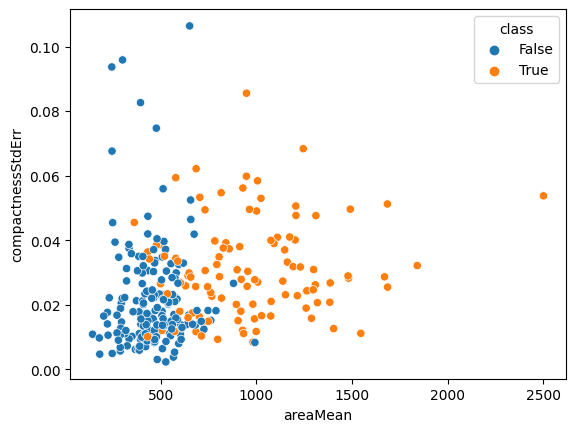

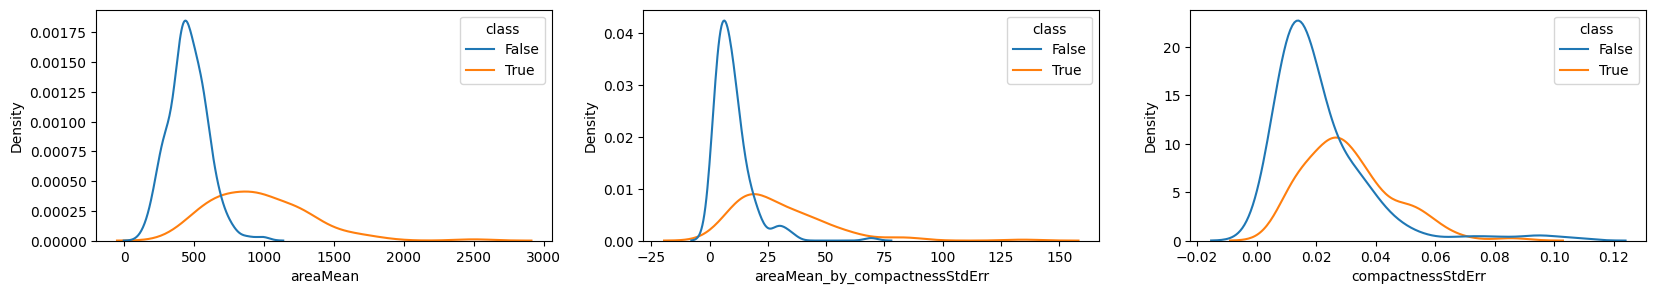

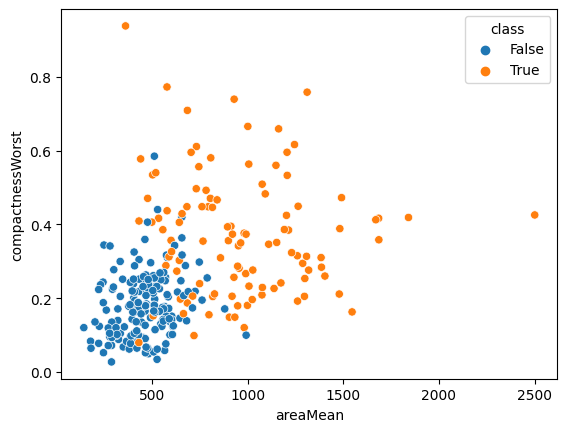

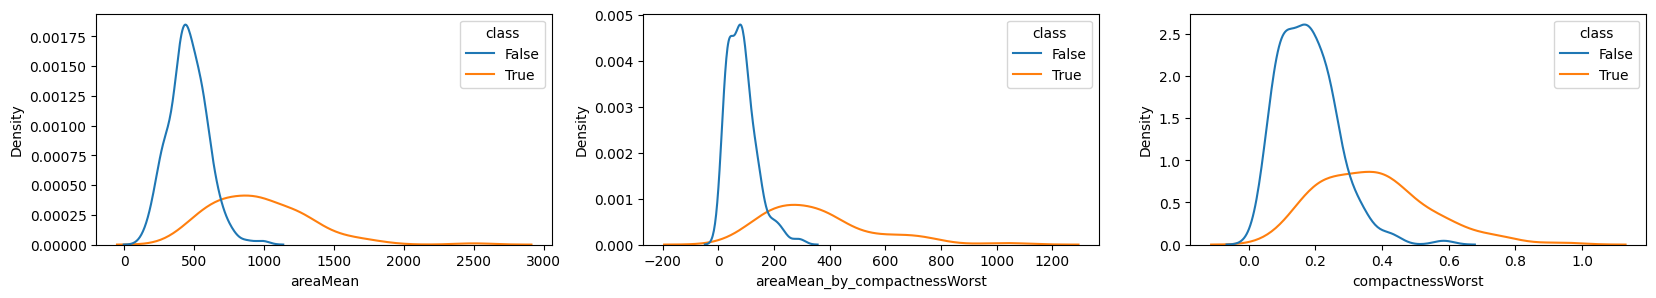

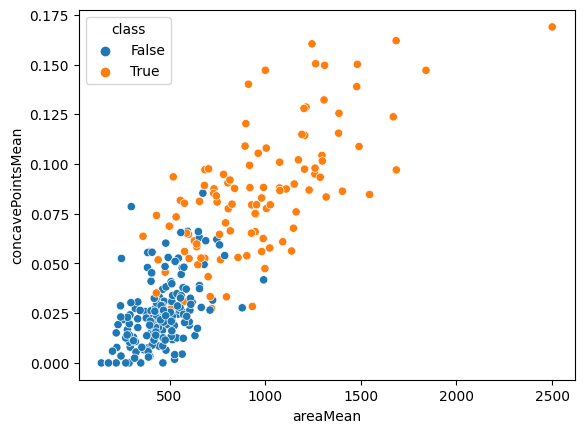

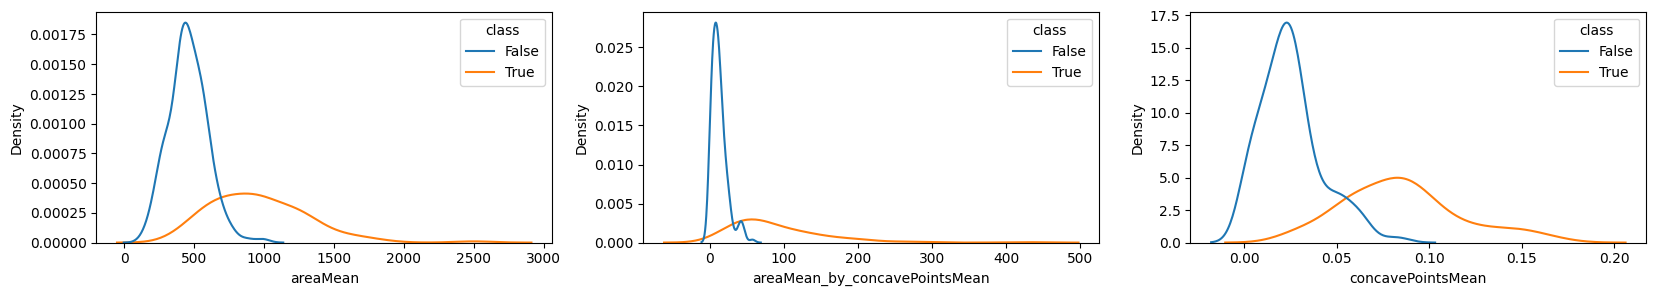

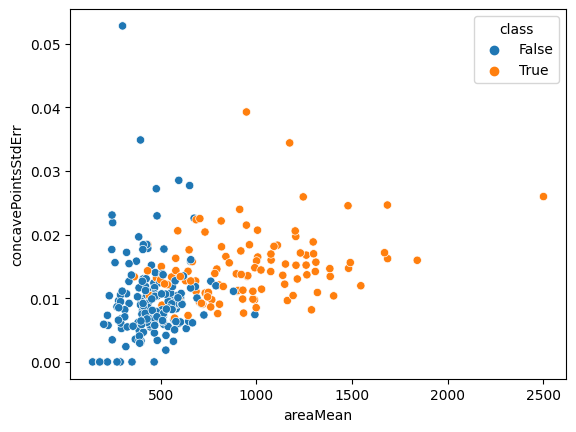

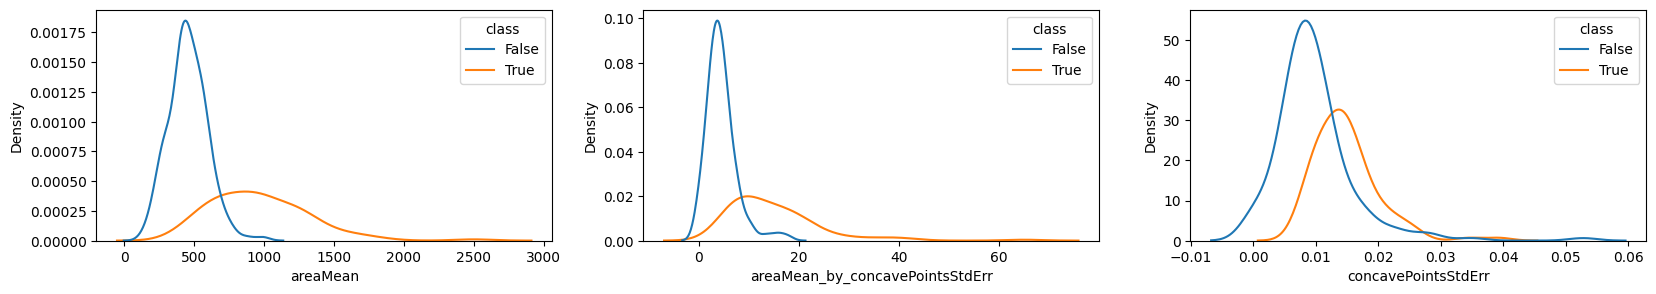

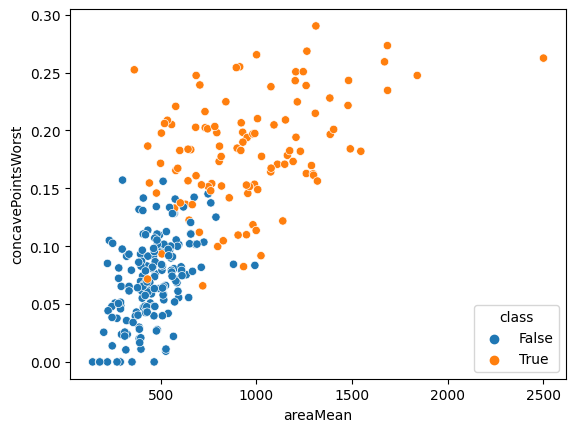

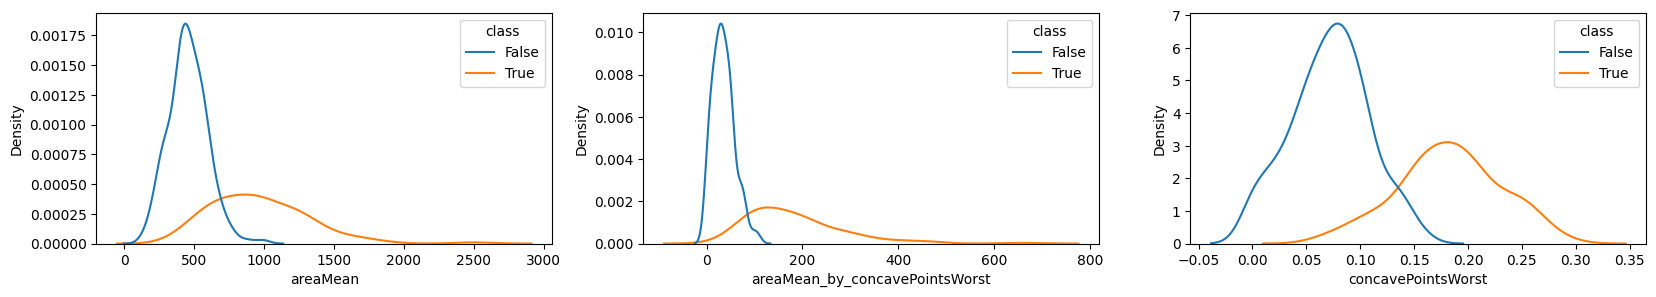

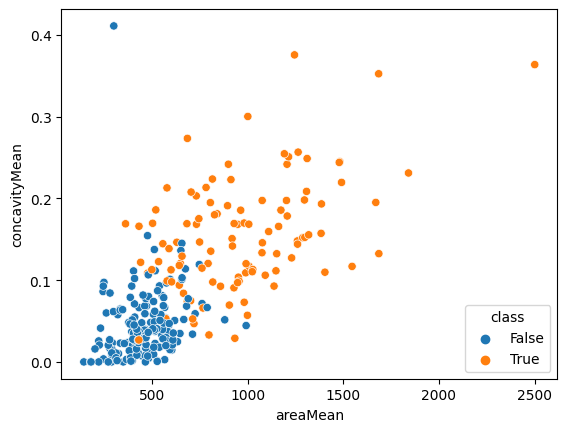

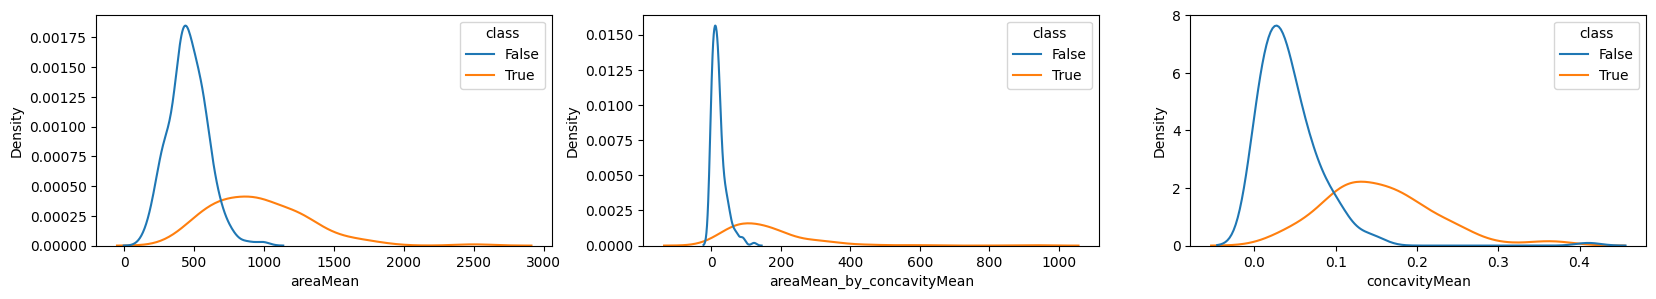

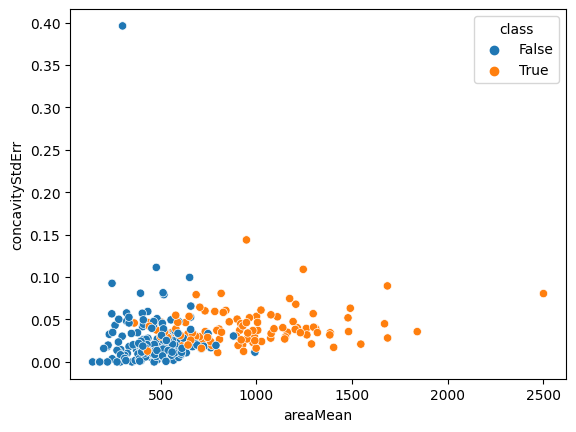

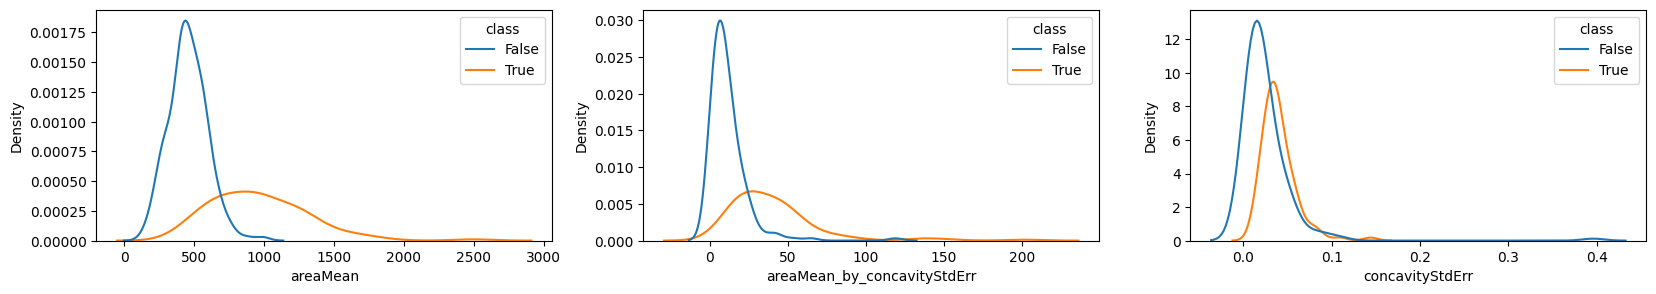

In [89]:
new_feat_df_train = pd.DataFrame({t[2]: t[3] for t in new_cols_train})
new_feat_df_train

new_feat_df_test = pd.DataFrame({t[2]: t[3] for t in new_cols_test})
new_feat_df_test

df_raw_labeled = pd.concat([df_raw_labeled, new_feat_df_train], axis=1)
df_raw_test = pd.concat([df_raw_test, new_feat_df_test], axis=1)

for new_feat in new_cols_train[0:10]:
    col1 = new_feat[0]
    col2 = new_feat[1]
    out_col = new_feat[2]

    plt.figure()
    sns.scatterplot(data=df_raw_labeled, x=col1, y=col2, hue="class")
    
    fig, ax = plt.subplots(1,3, figsize=(20, 3))
    sns.kdeplot(data=df_raw_labeled, x=col1, hue="class", ax=ax[0])
    sns.kdeplot(data=df_raw_labeled, x=out_col, hue="class", ax=ax[1])
    sns.kdeplot(data=df_raw_labeled, x=col2, hue="class", ax=ax[2])

In [90]:
# plt.figure()

# col1 = "radiusStdErr"
# col2 = "concavePointsMean"
# out_col = "radius_by_concave_mean"

# sns.scatterplot(data=df_raw_labeled, x=col1, y=col2, hue="class")

# df_raw_labeled[out_col] = df_raw_labeled[col1] * (df_raw_labeled[col2]+0.0001)
# df_raw_test[out_col] = df_raw_test[col1] * (df_raw_test[col2]+0.0001)

# fig, ax = plt.subplots(1,3, figsize=(20, 5))
# sns.kdeplot(data=df_raw_labeled, x=col1, hue="class", ax=ax[0])
# sns.kdeplot(data=df_raw_labeled, x=out_col, hue="class", ax=ax[1])
# sns.kdeplot(data=df_raw_labeled, x=col2, hue="class", ax=ax[2])

<Axes: xlabel='areaMean', ylabel='Density'>

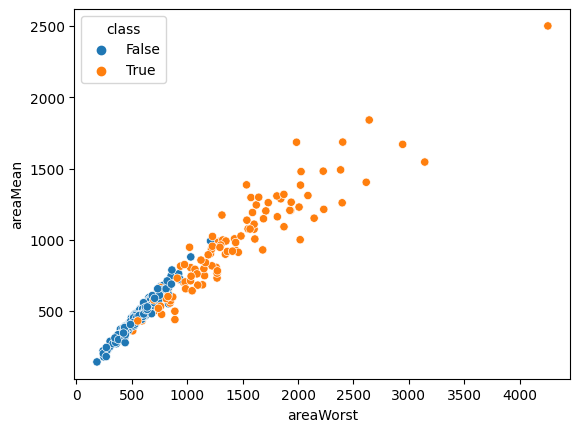

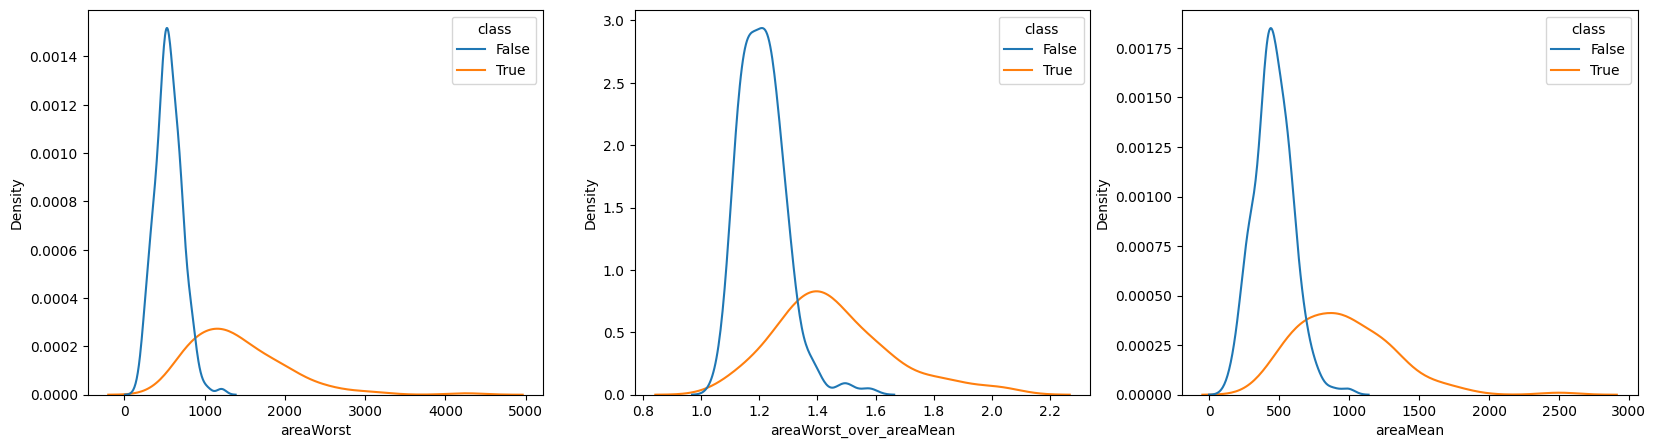

In [91]:
plt.figure()

col1 = "areaWorst"
col2 = "areaMean"
out_col = f"{col1}_over_{col2}"

sns.scatterplot(data=df_raw_labeled, x=col1, y=col2, hue="class")

df_raw_labeled[out_col] = df_raw_labeled[col1] / (df_raw_labeled[col2]+0.0001)
df_raw_test[out_col] = df_raw_test[col1] / (df_raw_test[col2]+0.0001)

fig, ax = plt.subplots(1,3, figsize=(20, 5))
sns.kdeplot(data=df_raw_labeled, x=col1, hue="class", ax=ax[0])
sns.kdeplot(data=df_raw_labeled, x=out_col, hue="class", ax=ax[1])
sns.kdeplot(data=df_raw_labeled, x=col2, hue="class", ax=ax[2])

<Axes: xlabel='radiusMean', ylabel='Density'>

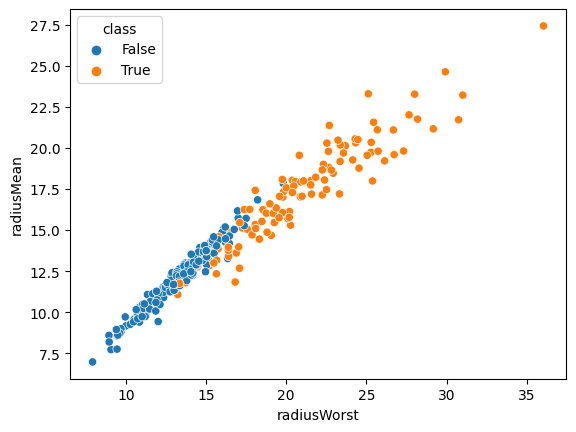

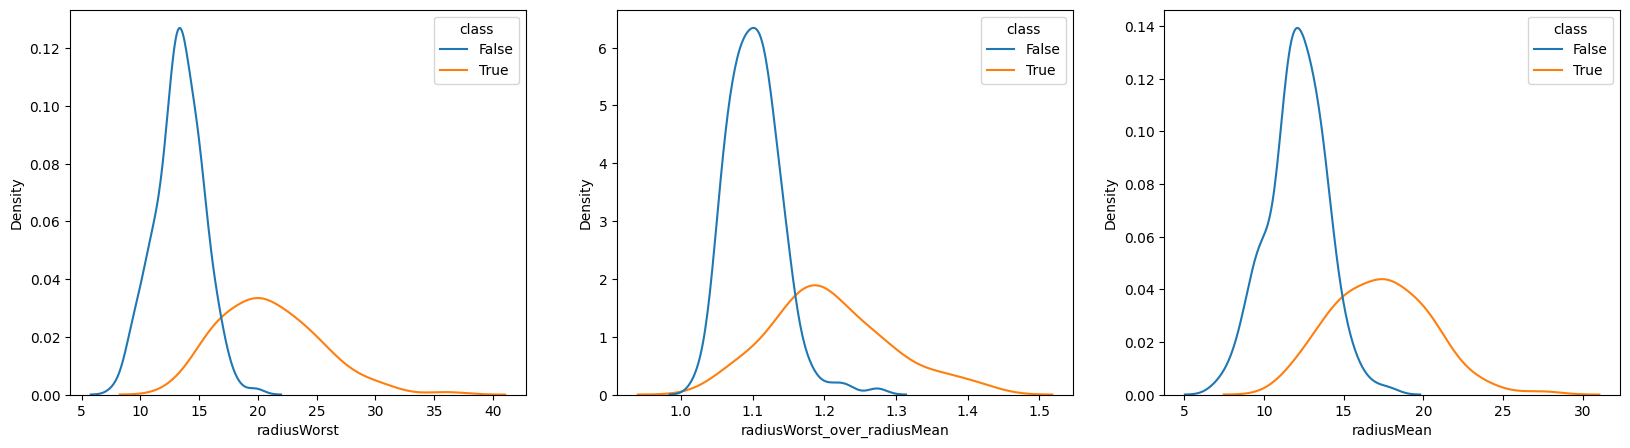

In [92]:
plt.figure()

col1 = "radiusWorst"
col2 = "radiusMean"
out_col = f"{col1}_over_{col2}"

sns.scatterplot(data=df_raw_labeled, x=col1, y=col2, hue="class")

df_raw_labeled[out_col] = df_raw_labeled[col1] / (df_raw_labeled[col2]+0.0001)
df_raw_test[out_col] = df_raw_test[col1] / (df_raw_test[col2]+0.0001)

fig, ax = plt.subplots(1,3, figsize=(20, 5))
sns.kdeplot(data=df_raw_labeled, x=col1, hue="class", ax=ax[0])
sns.kdeplot(data=df_raw_labeled, x=out_col, hue="class", ax=ax[1])
sns.kdeplot(data=df_raw_labeled, x=col2, hue="class", ax=ax[2])

<Axes: xlabel='radiusMean', ylabel='Density'>

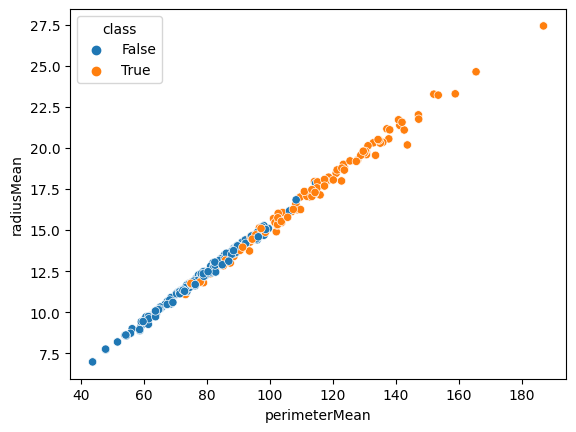

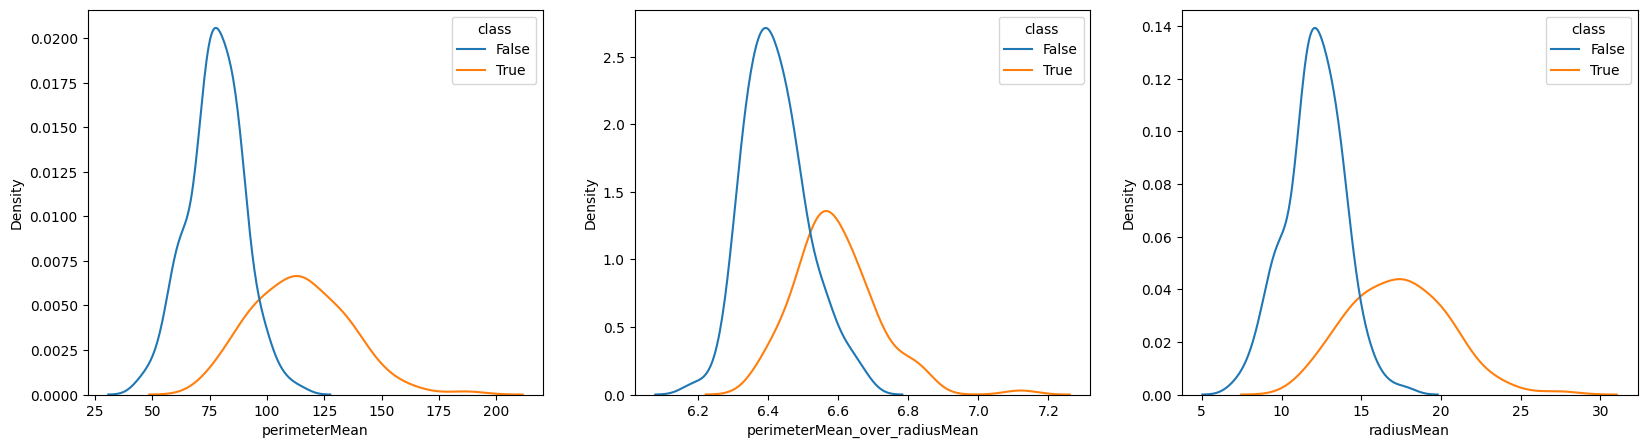

In [93]:
plt.figure()

col1 = "perimeterMean"
col2 = "radiusMean"
out_col = f"{col1}_over_{col2}"

sns.scatterplot(data=df_raw_labeled, x=col1, y=col2, hue="class")

df_raw_labeled[out_col] = df_raw_labeled[col1] / (df_raw_labeled[col2]+0.0001)
df_raw_test[out_col] = df_raw_test[col1] / (df_raw_test[col2]+0.0001)

fig, ax = plt.subplots(1,3, figsize=(20, 5))
sns.kdeplot(data=df_raw_labeled, x=col1, hue="class", ax=ax[0])
sns.kdeplot(data=df_raw_labeled, x=out_col, hue="class", ax=ax[1])
sns.kdeplot(data=df_raw_labeled, x=col2, hue="class", ax=ax[2])

<Axes: xlabel='radiusWorst', ylabel='Density'>

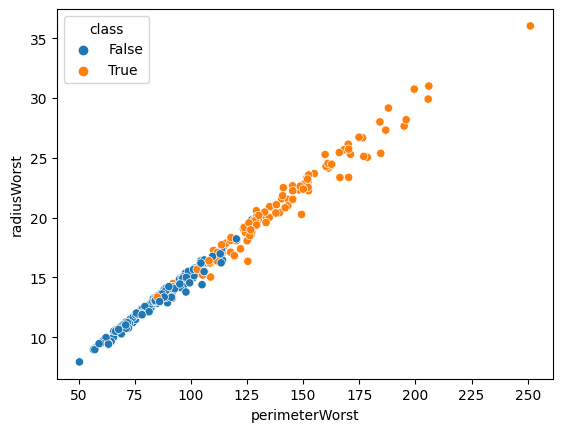

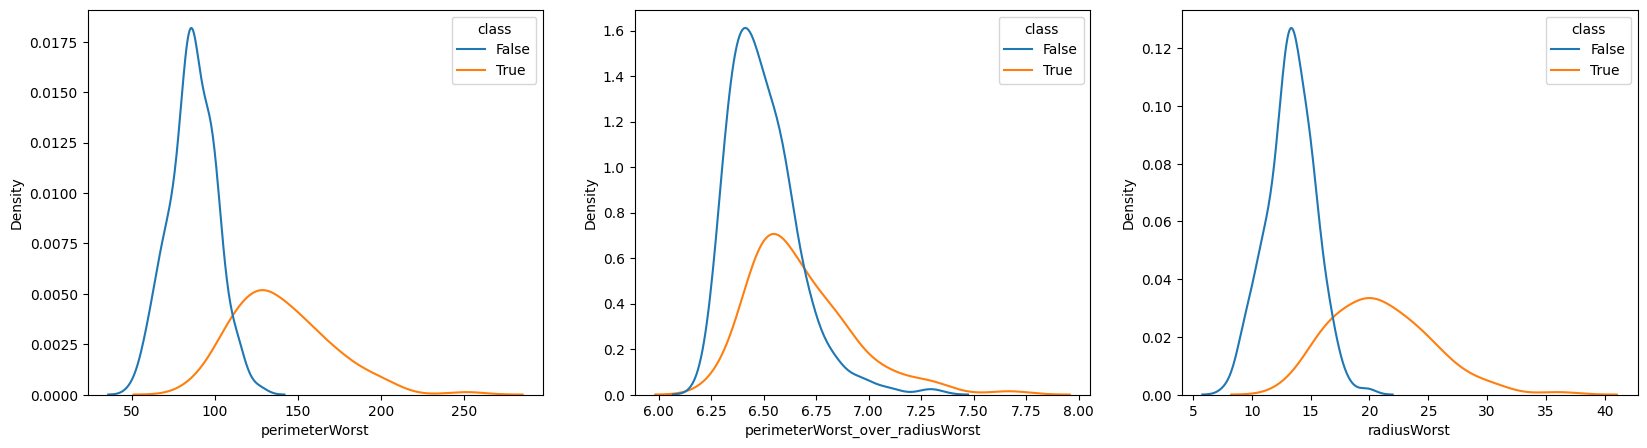

In [94]:
plt.figure()

col1 = "perimeterWorst"
col2 = "radiusWorst"
out_col = f"{col1}_over_{col2}"

sns.scatterplot(data=df_raw_labeled, x=col1, y=col2, hue="class")

df_raw_labeled[out_col] = df_raw_labeled[col1] / (df_raw_labeled[col2]+0.0001)
df_raw_test[out_col] = df_raw_test[col1] / (df_raw_test[col2]+0.0001)

fig, ax = plt.subplots(1,3, figsize=(20, 5))
sns.kdeplot(data=df_raw_labeled, x=col1, hue="class", ax=ax[0])
sns.kdeplot(data=df_raw_labeled, x=out_col, hue="class", ax=ax[1])
sns.kdeplot(data=df_raw_labeled, x=col2, hue="class", ax=ax[2])

<Axes: xlabel='areaMean', ylabel='Density'>

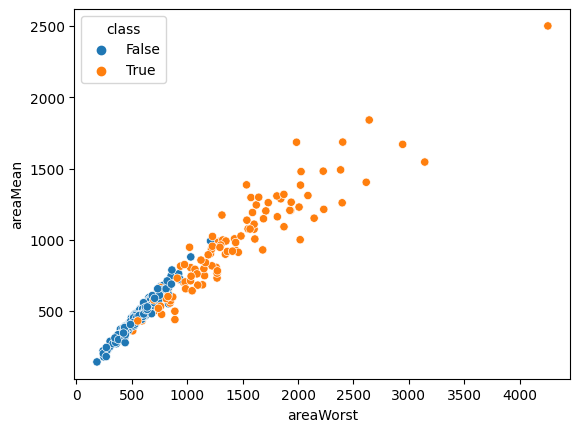

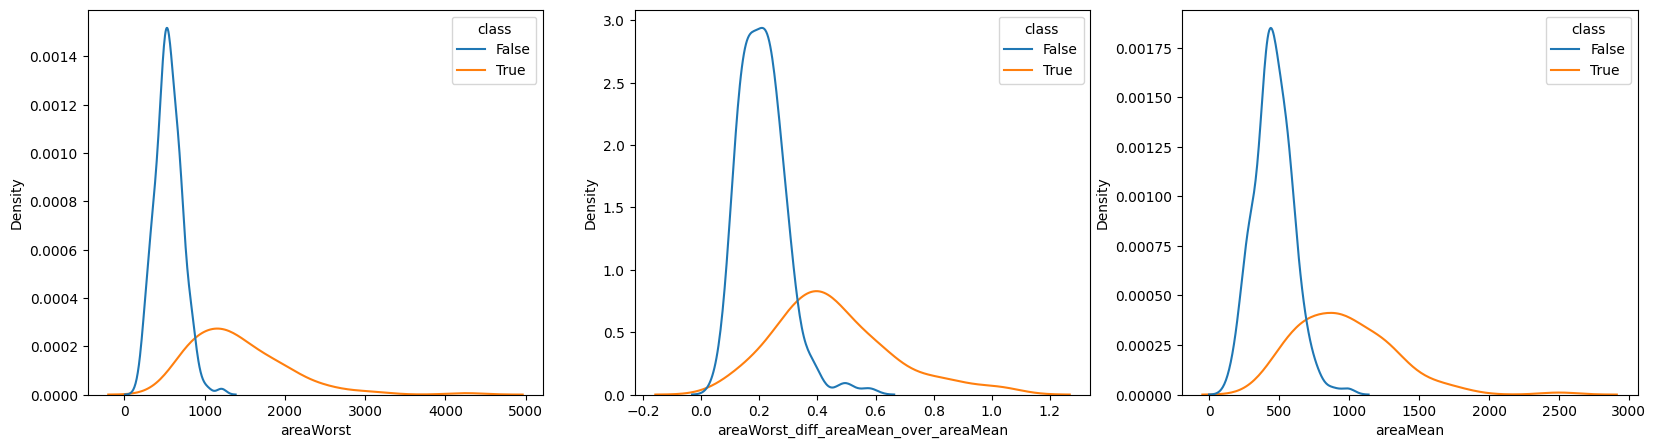

In [95]:
plt.figure()

col1 = "areaWorst"
col2 = "areaMean"
out_col = f"{col1}_diff_{col2}_over_{col2}"

sns.scatterplot(data=df_raw_labeled, x=col1, y=col2, hue="class")

df_raw_labeled[out_col] = (df_raw_labeled[col1] - df_raw_labeled[col2]) / (df_raw_labeled[col2]+0.0001)
df_raw_test[out_col] = (df_raw_test[col1] - df_raw_test[col2]) / (df_raw_test[col2]+0.0001)

fig, ax = plt.subplots(1,3, figsize=(20, 5))
sns.kdeplot(data=df_raw_labeled, x=col1, hue="class", ax=ax[0])
sns.kdeplot(data=df_raw_labeled, x=out_col, hue="class", ax=ax[1])
sns.kdeplot(data=df_raw_labeled, x=col2, hue="class", ax=ax[2])

<Axes: xlabel='areaWorst', ylabel='Density'>

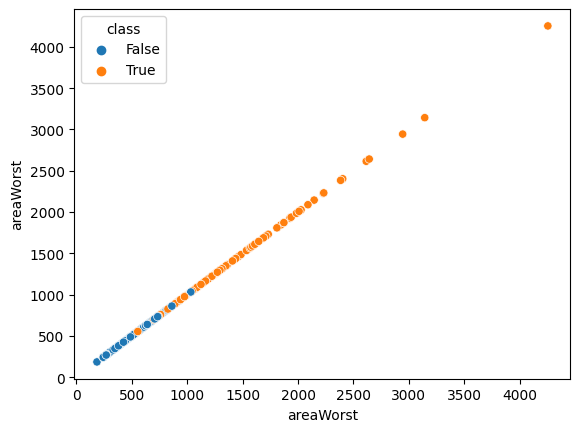

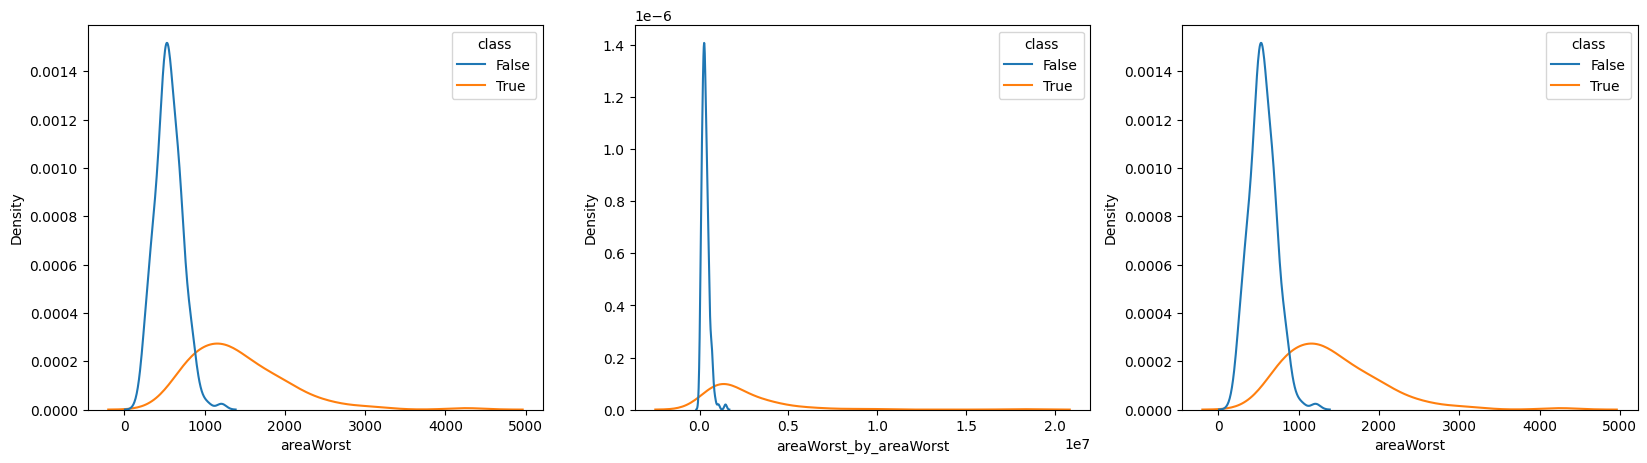

In [96]:
plt.figure()

col1 = "areaWorst"
col2 = "areaWorst"
out_col = f"{col1}_by_{col2}"

sns.scatterplot(data=df_raw_labeled, x=col1, y=col2, hue="class")

df_raw_labeled[out_col] = df_raw_labeled[col1] * df_raw_labeled[col2]
df_raw_test[out_col] = df_raw_test[col1] * df_raw_test[col2]

fig, ax = plt.subplots(1,3, figsize=(20, 5))
sns.kdeplot(data=df_raw_labeled, x=col1, hue="class", ax=ax[0])
sns.kdeplot(data=df_raw_labeled, x=out_col, hue="class", ax=ax[1])
sns.kdeplot(data=df_raw_labeled, x=col2, hue="class", ax=ax[2])

<Axes: xlabel='areaMean', ylabel='Density'>

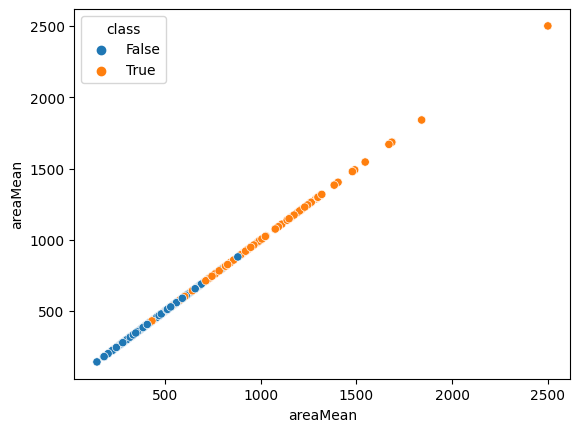

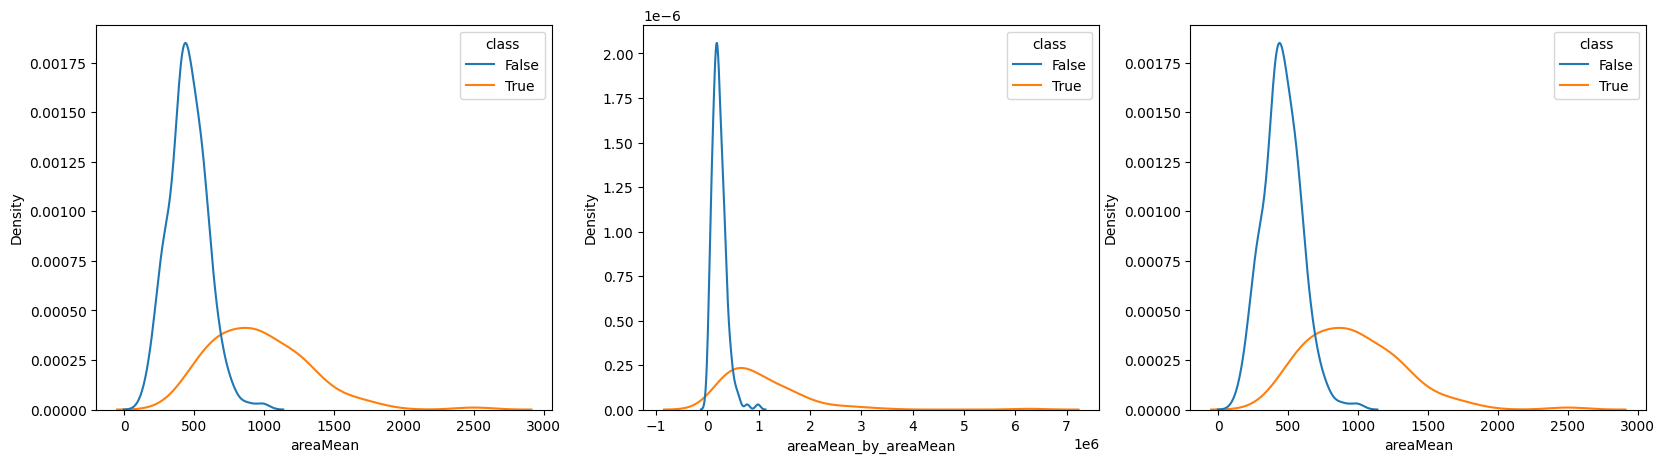

In [97]:
plt.figure()

col1 = "areaMean"
col2 = "areaMean"
out_col = f"{col1}_by_{col2}"

sns.scatterplot(data=df_raw_labeled, x=col1, y=col2, hue="class")

df_raw_labeled[out_col] = df_raw_labeled[col1] * df_raw_labeled[col2]
df_raw_test[out_col] = df_raw_test[col1] * df_raw_test[col2]

fig, ax = plt.subplots(1,3, figsize=(20, 5))
sns.kdeplot(data=df_raw_labeled, x=col1, hue="class", ax=ax[0])
sns.kdeplot(data=df_raw_labeled, x=out_col, hue="class", ax=ax[1])
sns.kdeplot(data=df_raw_labeled, x=col2, hue="class", ax=ax[2])

In [98]:
(df_raw_labeled == np.inf).sum()

ID                                       0
class                                    0
radiusMean                               0
textureMean                              0
perimeterMean                            0
                                        ..
perimeterMean_over_radiusMean            0
perimeterWorst_over_radiusWorst          0
areaWorst_diff_areaMean_over_areaMean    0
areaWorst_by_areaWorst                   0
areaMean_by_areaMean                     0
Length: 474, dtype: int64

## Modeling

In [99]:
step = "FeatureEngineering"

In [100]:
cv_seeds=[0, 1, 7, 42, 100, 120, 123, 666, 999, 100000]
train_cv_dfs, test_cv_dfs = prepare_cv_datasets(df=df_raw_labeled, cv_seeds=cv_seeds, lbl_col="class")

Train rows: 199
Test rows: 86
Train rows: 199
Test rows: 86
Train rows: 199
Test rows: 86
Train rows: 199
Test rows: 86
Train rows: 199
Test rows: 86
Train rows: 199
Test rows: 86
Train rows: 199
Test rows: 86
Train rows: 199
Test rows: 86
Train rows: 199
Test rows: 86
Train rows: 199
Test rows: 86


### LogisticRegression

,Training Precision,Training Recall,Training F1
0,0.999184,0.99871,0.998941


,Test Precision,Test Recall,Test F1
0,0.958791,0.962688,0.960191


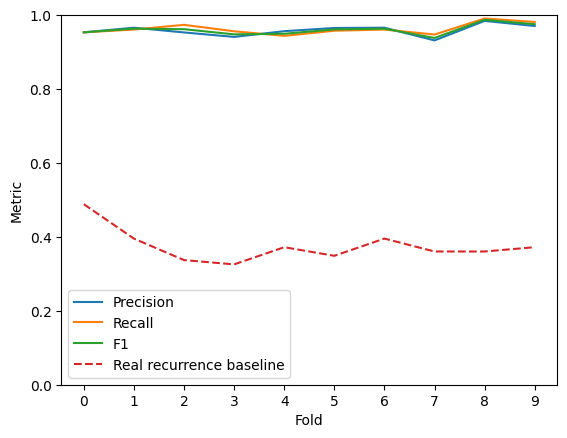

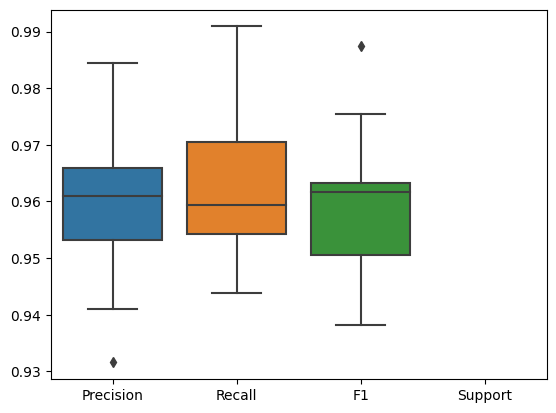

In [101]:
train_prfs_arr = np.empty((len(cv_seeds), 4))
test_prfs_arr = np.empty((len(cv_seeds), 4))

proportion_lbls_test = np.empty((len(cv_seeds)))

for idx, fold in enumerate(zip(train_cv_dfs, test_cv_dfs)):
    X_train, y_train = fold[0]
    X_test, y_test = fold[1]

    proportion_lbls_test[idx] = y_test.sum() / y_test.count() 
    
    logistic_reg = LogisticRegression(random_state=42)
    logistic_reg.fit(X_train, y_train)
    
    train_y_pred = logistic_reg.predict(X_train)
    test_y_pred = logistic_reg.predict(X_test)
    
    #display_train_test_confusion_matrix(y_train=y_train, y_test=y_test, train_y_pred=train_y_pred, test_y_pred=test_y_pred)
    
    train_prfs = precision_recall_fscore_support(y_train, train_y_pred, average='macro')
    test_prfs = precision_recall_fscore_support(y_test, test_y_pred, average='macro')

    train_prfs_arr[idx] = train_prfs
    test_prfs_arr[idx] = test_prfs

plt.plot(test_prfs_arr[:, 0], label="Precision")
plt.plot(test_prfs_arr[:, 1], label="Recall")
plt.plot(test_prfs_arr[:, 2], label="F1")
plt.xticks(range(test_prfs_arr.shape[0]))
plt.ylabel("Metric")
plt.xlabel("Fold")
plt.ylim(0.0, 1.0)
plt.plot(proportion_lbls_test, label="Real recurrence baseline", linestyle="--")
plt.legend()

train_cv_prfs = train_prfs_arr.mean(axis=0)
test_cv_prfs = test_prfs_arr.mean(axis=0)

print_prfs(prfs=train_cv_prfs, label="Training")
print_prfs(prfs=test_cv_prfs, label="Test")

plt.figure()
sns.boxplot(test_prfs_arr)
ticks = plt.xticks()[0]
plt.xticks(ticks=ticks, labels=["Precision", "Recall", "F1", "Support"])
#plt.ylim(0.0, 1.0)

METRICS["LogisticRegression"][step] = {}
METRICS["LogisticRegression"][step]["train"] = tuple(train_cv_prfs)
METRICS["LogisticRegression"][step]["test"] = tuple(test_cv_prfs)

## XGboost

,Training Precision,Training Recall,Training F1
0,1.0,1.0,1.0


,Test Precision,Test Recall,Test F1
0,0.952861,0.955953,0.953639


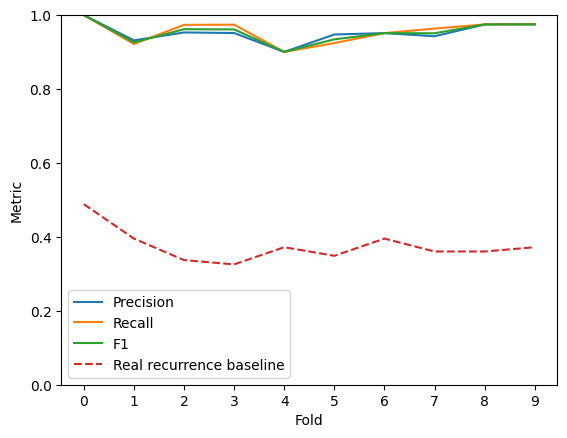

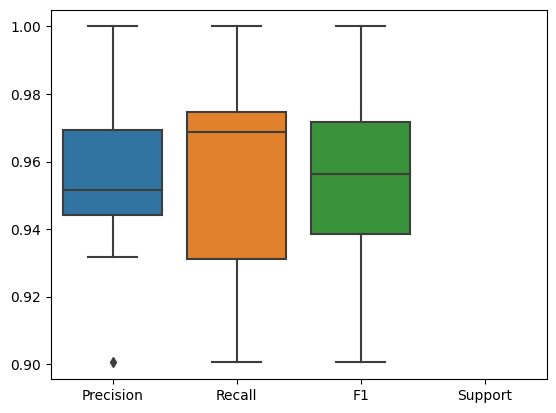

In [102]:
train_prfs_arr = np.empty((len(cv_seeds), 4))
test_prfs_arr = np.empty((len(cv_seeds), 4))

proportion_lbls_test = np.empty((len(cv_seeds)))

for idx, fold in enumerate(zip(train_cv_dfs, test_cv_dfs)):
    X_train, y_train = fold[0]
    X_test, y_test = fold[1]

    proportion_lbls_test[idx] = y_test.sum() / y_test.count() 
    
    xgbc_baseline = XGBClassifier(random_state=42)
    xgbc_baseline.fit(X_train, y_train)
    
    train_y_pred = xgbc_baseline.predict(X_train)
    test_y_pred = xgbc_baseline.predict(X_test)
    
    #display_train_test_confusion_matrix(y_train=y_train, y_test=y_test, train_y_pred=train_y_pred, test_y_pred=test_y_pred)
    
    train_prfs = precision_recall_fscore_support(y_train, train_y_pred, average='macro')
    test_prfs = precision_recall_fscore_support(y_test, test_y_pred, average='macro')

    train_prfs_arr[idx] = train_prfs
    test_prfs_arr[idx] = test_prfs

plt.plot(test_prfs_arr[:, 0], label="Precision")
plt.plot(test_prfs_arr[:, 1], label="Recall")
plt.plot(test_prfs_arr[:, 2], label="F1")
plt.xticks(range(test_prfs_arr.shape[0]))
plt.ylabel("Metric")
plt.xlabel("Fold")
plt.ylim(0.0, 1.0)
plt.plot(proportion_lbls_test, label="Real recurrence baseline", linestyle="--")
plt.legend()

train_cv_prfs = train_prfs_arr.mean(axis=0)
test_cv_prfs = test_prfs_arr.mean(axis=0)

print_prfs(prfs=train_cv_prfs, label="Training")
print_prfs(prfs=test_cv_prfs, label="Test")

plt.figure()
sns.boxplot(test_prfs_arr)
ticks = plt.xticks()[0]
plt.xticks(ticks=ticks, labels=["Precision", "Recall", "F1", "Support"])
#plt.ylim(0.0, 1.0)

METRICS["XGBClassifier"][step] = {}
METRICS["XGBClassifier"][step]["train"] = tuple(train_cv_prfs)
METRICS["XGBClassifier"][step]["test"] = tuple(test_cv_prfs)

### SVM

,Training Precision,Training Recall,Training F1
0,0.986804,0.979268,0.982785


,Test Precision,Test Recall,Test F1
0,0.971936,0.970733,0.971101


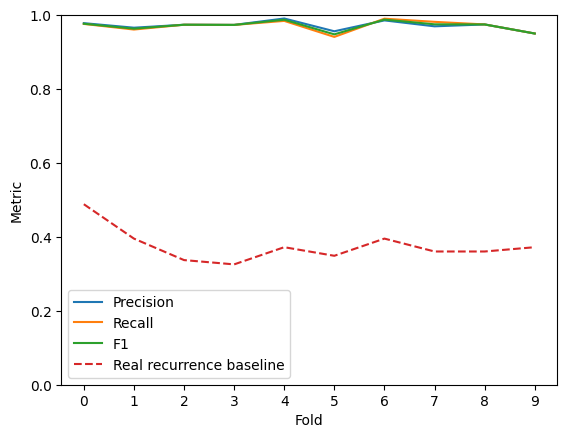

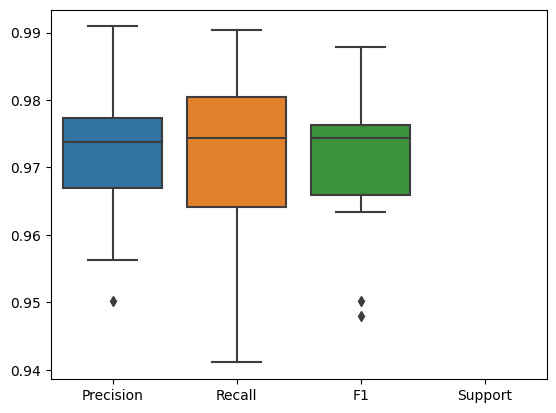

In [103]:
train_prfs_arr = np.empty((len(cv_seeds), 4))
test_prfs_arr = np.empty((len(cv_seeds), 4))

proportion_lbls_test = np.empty((len(cv_seeds)))

for idx, fold in enumerate(zip(train_cv_dfs, test_cv_dfs)):
    X_train, y_train = fold[0]
    X_test, y_test = fold[1]

    proportion_lbls_test[idx] = y_test.sum() / y_test.count() 
    
    clf = svm.SVC(random_state=42)
    clf.fit(X_train, y_train)
    
    train_y_pred = clf.predict(X_train)
    test_y_pred = clf.predict(X_test)
    
    #display_train_test_confusion_matrix(y_train=y_train, y_test=y_test, train_y_pred=train_y_pred, test_y_pred=test_y_pred)
    
    train_prfs = precision_recall_fscore_support(y_train, train_y_pred, average='macro')
    test_prfs = precision_recall_fscore_support(y_test, test_y_pred, average='macro')

    train_prfs_arr[idx] = train_prfs
    test_prfs_arr[idx] = test_prfs
plt.plot(test_prfs_arr[:, 0], label="Precision")
plt.plot(test_prfs_arr[:, 1], label="Recall")
plt.plot(test_prfs_arr[:, 2], label="F1")
plt.xticks(range(test_prfs_arr.shape[0]))
plt.ylabel("Metric")
plt.xlabel("Fold")
plt.ylim(0.0, 1.0)
plt.plot(proportion_lbls_test, label="Real recurrence baseline", linestyle="--")
plt.legend()

train_cv_prfs = train_prfs_arr.mean(axis=0)
test_cv_prfs = test_prfs_arr.mean(axis=0)

print_prfs(prfs=train_cv_prfs, label="Training")
print_prfs(prfs=test_cv_prfs, label="Test")

plt.figure()
sns.boxplot(test_prfs_arr)
ticks = plt.xticks()[0]
plt.xticks(ticks=ticks, labels=["Precision", "Recall", "F1", "Support"])
#plt.ylim(0.0, 1.0)

METRICS["SVM"][step] = {}
METRICS["SVM"][step]["train"] = tuple(train_cv_prfs)
METRICS["SVM"][step]["test"] = tuple(test_cv_prfs)

## Metrics so far

(0.9587907454030118, 0.9626875643272031, 0.9601912246218021, nan)
(0.9528607413860728, 0.9559525196877467, 0.9536388319237472, nan)
(0.9719362962868372, 0.970733295112872, 0.9711005104263233, nan)


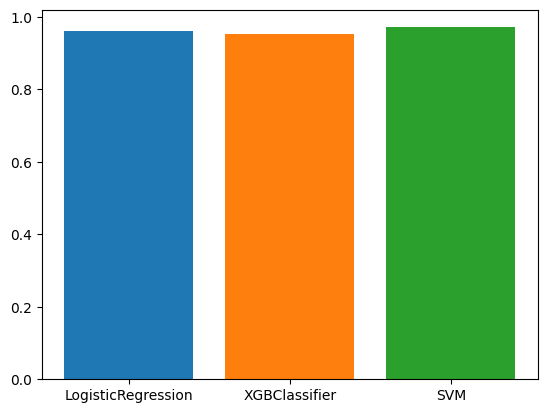

In [104]:
for k,v in METRICS.items():
    print(v[step]["test"])

    plt.bar(x=k, height=v[step]["test"][2])

In [105]:
print(json.dumps(METRICS, indent=4))

{
    "LogisticRegression": {
        "Baseline": {
            "train": [
                0.9928094003905628,
                0.9880805355747061,
                0.9903358587689869,
                NaN
            ],
            "test": [
                0.9590103646062971,
                0.9592824297104077,
                0.9587062005225739,
                NaN
            ]
        },
        "FeatureEngineering": {
            "train": [
                0.9991836598693856,
                0.9987096237096237,
                0.9989407790196922,
                NaN
            ],
            "test": [
                0.9587907454030118,
                0.9626875643272031,
                0.9601912246218021,
                NaN
            ]
        }
    },
    "XGBClassifier": {
        "Baseline": {
            "train": [
                1.0,
                1.0,
                1.0,
                NaN
            ],
            "test": [
                0.9357942913750528,
    

## Final Feature Engineering Model

In [106]:
X_train, y_train = get_X_y(df_raw_labeled, lbl_col="class")
X_test = df_raw_test.drop("ID", axis=1)

scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

xgbc = XGBClassifier(random_state=42)
xgbc.fit(X_train, y_train)

train_y_pred = xgbc.predict(X_train)
test_y_pred = xgbc.predict(X_test)

train_prfs = precision_recall_fscore_support(y_train, train_y_pred, average='macro')
train_prfs

(1.0, 1.0, 1.0, None)

In [107]:
submission_dt = dt.datetime.now().strftime("%Y%m%d_%H%M%S")

submission = pd.DataFrame({"ID": df_raw_test["ID"], "class": test_y_pred})
submission = submission.replace({0: "false", 1: "true"})
submission 

save_path = "submissions/feat_engineering/xgb"
sub = "."
for part in save_path.split("/"):
    sub = sub + "/" + part 
    try:
        os.mkdir(sub)
        print(f"Created path {sub}")
    except FileExistsError:
        print(f"Path {sub} already exists.")
        pass

submission.to_csv(f"{save_path}/submission_logreg_{submission_dt}.csv", index=False)

Path ./submissions already exists.
Path ./submissions/feat_engineering already exists.
Path ./submissions/feat_engineering/xgb already exists.


In [108]:
submission.groupby("class").count()

,ID
class,
false,184
true,100


In [109]:
X_train, y_train = get_X_y(df_raw_labeled, lbl_col="class")
X_test = df_raw_test.drop("ID", axis=1)

scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

train_y_pred = log_reg.predict(X_train)
test_y_pred = log_reg.predict(X_test)

train_prfs = precision_recall_fscore_support(y_train, train_y_pred, average='macro')
train_prfs

(0.994413407821229, 0.9907407407407407, 0.9925181140396935, None)

In [110]:
submission_dt = dt.datetime.now().strftime("%Y%m%d_%H%M%S")

submission = pd.DataFrame({"ID": df_raw_test["ID"], "class": test_y_pred})
submission = submission.replace({False: "false", True: "true"})
submission 

save_path = "submissions/feat_engineering/log_reg"
sub = "."
for part in save_path.split("/"):
    sub = sub + "/" + part 
    try:
        os.mkdir(sub)
        print(f"Created path {sub}")
    except FileExistsError:
        print(f"Path {sub} already exists.")
        pass

submission.to_csv(f"{save_path}/submission_xgb_{submission_dt}.csv", index=False)

Path ./submissions already exists.
Path ./submissions/feat_engineering already exists.
Path ./submissions/feat_engineering/log_reg already exists.


In [111]:
submission.groupby("class").count()

,ID
class,
false,182
true,102


In [113]:
X_train, y_train = get_X_y(df_raw_labeled, lbl_col="class")
X_test = df_raw_test.drop("ID", axis=1)

scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

clf = svm.SVC(random_state=42)
clf.fit(X_train, y_train)

train_y_pred = clf.predict(X_train)
test_y_pred = clf.predict(X_test)

train_prfs = precision_recall_fscore_support(y_train, train_y_pred, average='macro')
train_prfs

(0.9841269841269842, 0.9786566227244193, 0.9812601096776739, None)

In [114]:
test_y_pred

array([False, False, False, False,  True, False, False, False, False,
       False,  True, False,  True, False, False, False, False, False,
        True,  True,  True, False, False,  True,  True, False, False,
       False, False, False, False,  True, False,  True, False,  True,
       False, False,  True, False, False, False, False,  True, False,
       False, False, False,  True, False, False, False, False,  True,
       False, False,  True,  True, False,  True,  True, False, False,
        True, False,  True, False, False, False,  True, False, False,
        True,  True, False, False,  True,  True, False, False, False,
       False, False,  True, False, False, False,  True,  True, False,
       False,  True,  True, False, False, False, False, False, False,
        True,  True,  True, False,  True, False,  True, False, False,
       False, False,  True, False, False,  True, False,  True, False,
       False,  True, False, False, False,  True, False,  True,  True,
       False, False,

In [115]:
submission_dt = dt.datetime.now().strftime("%Y%m%d_%H%M%S")

submission = pd.DataFrame({"ID": df_raw_test["ID"], "class": test_y_pred})
submission = submission.replace({False: "false", True: "true"})
submission 

save_path = "submissions/feat_engineering/svm"
sub = "."
for part in save_path.split("/"):
    sub = sub + "/" + part 
    try:
        os.mkdir(sub)
        print(f"Created path {sub}")
    except FileExistsError:
        print(f"Path {sub} already exists.")
        pass

submission.to_csv(f"{save_path}/submission_svm_{submission_dt}.csv", index=False)

Path ./submissions already exists.
Path ./submissions/feat_engineering already exists.
Created path ./submissions/feat_engineering/svm


In [112]:
# df_logreg_importance = pd.DataFrame({"feature": df_raw_test.drop("ID", axis=1).columns, "coef": logistic_reg.coef_[0]})

# sns.barplot(data=df_logreg_importance, x="feature", y="coef")
# plt.xticks(rotation=90);